# 📈 Time Series Analysis

---

### 🎯 Learning Objectives

Setelah menyelesaikan praktikum ini, peserta akan mampu:

1. Memahami karakteristik data time series dan perbedaannya dengan data cross-sectional
2. Mengidentifikasi komponen time series: trend, seasonality, dan residual
3. Menerapkan teknik smoothing (Moving Average & Exponential Smoothing)
4. Menguji stationarity dan menginterpretasi ACF/PACF
5. Membangun model forecasting dengan ARIMA dan Prophet
6. Menginterpretasi hasil forecasting untuk pengambilan keputusan bisnis

### 📦 Dataset

Kita akan menggunakan **Airline Passengers Dataset**. Dataset ini ideal karena:
- Memiliki trend yang jelas (naik)
- Memiliki seasonality yang kuat (pola tahunan)
- Ukuran kecil dan mudah dipahami
- Relevan dengan business use case (forecasting demand)

---

## ⚙️ Setup & Installation

Jalankan cell di bawah ini untuk menginstall library yang diperlukan.

In [ ]:
# Install required packages
!pip install prophet statsmodels pandas matplotlib seaborn plotly -q

print("✅ Installation complete!")

✅ Installation complete!


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Statsmodels imports
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Prophet
from prophet import Prophet

# Sklearn for metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---

# 📚 Section 1: Introduction to Time Series Data

## 1.1 Apa itu Time Series?

**Time Series** adalah sekumpulan data points yang dikumpulkan pada interval waktu yang teratur.

### Karakteristik Utama:
- Data diurutkan berdasarkan waktu
- Observasi pada waktu yang berbeda saling berhubungan (temporal dependence)
- Urutan data sangat penting (tidak bisa diacak)

### Time Series vs Cross-Sectional Data

| Aspek | Time Series | Cross-Sectional |
|-------|-------------|------------------|
| **Definisi** | Data satu variabel yang diamati dari waktu ke waktu | Data banyak variabel yang diamati pada satu titik waktu |
| **Contoh** | Penjualan harian toko A selama 1 tahun | Penjualan 100 toko berbeda pada bulan Januari |
| **Urutan** | Sangat penting | Tidak penting |
| **Asumsi** | Observasi bisa berkorelasi | Observasi independen |
| **Tujuan Utama** | Forecasting, pattern detection | Comparison, relationship analysis |

---

## 1.2 Load Dataset

In [ ]:
# Load Airline Passengers dataset dari URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Preview data
print("📊 Dataset Preview:")
print("="*50)
display(df.head(10))
print(f"\n📏 Shape: {df.shape[0]} rows x {df.shape[1]} columns")

📊 Dataset Preview:


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119



📏 Shape: 144 rows x 2 columns


In [ ]:
  # Data info dan basic statistics
print("📋 Data Info:")
print("="*50)
print(df.info())
print("\n📈 Basic Statistics:")
print("="*50)
display(df.describe())

📋 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None

📈 Basic Statistics:


,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [ ]:
# Data preprocessing - convert to proper datetime format
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df.columns = ['Passengers']  # Rename column for clarity

# Verify the transformation
print("✅ Data transformed:")
print(f"   Index type: {type(df.index)}")
print(f"   Date range: {df.index.min()} to {df.index.max()}")
print(f"   Frequency: Monthly")
display(df.head())

✅ Data transformed:
   Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
   Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00
   Frequency: Monthly


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## 1.3 Visualisasi Data Time Series

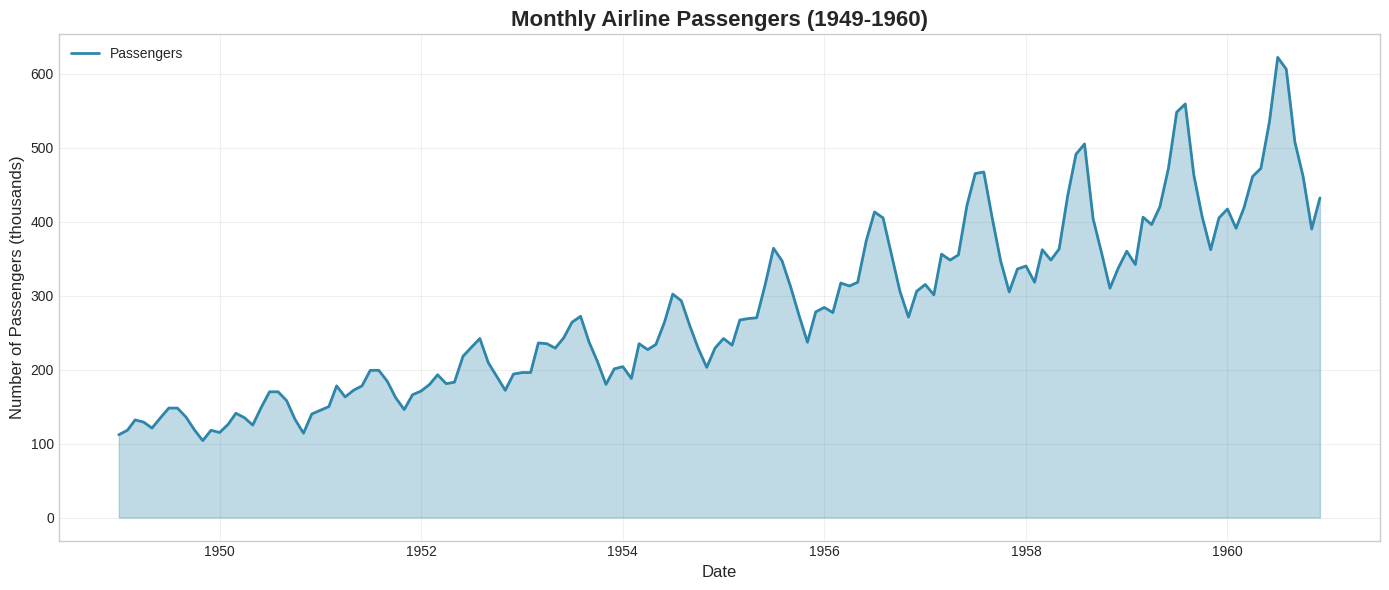


🔍 Observasi awal:
   1. Ada TREND naik yang jelas dari waktu ke waktu
   2. Ada SEASONALITY - pola yang berulang setiap tahun
   3. Variance meningkat seiring waktu (heteroskedasticity)


In [ ]:
# Basic time series plot dengan matplotlib
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['Passengers'], color='#2E86AB', linewidth=2, label='Passengers')
ax.fill_between(df.index, df['Passengers'], alpha=0.3, color='#2E86AB')

ax.set_title('Monthly Airline Passengers (1949-1960)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Passengers (thousands)', fontsize=12)
ax.legend(loc='upper left')

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 Observasi awal:")
print("   1. Ada TREND naik yang jelas dari waktu ke waktu")
print("   2. Ada SEASONALITY - pola yang berulang setiap tahun")
print("   3. Variance meningkat seiring waktu (heteroskedasticity)")

In [ ]:
# Interactive plot dengan Plotly
fig = px.line(df.reset_index(), x='Month', y='Passengers',
              title='Interactive: Monthly Airline Passengers (1949-1960)',
              labels={'Passengers': 'Number of Passengers (thousands)', 'Month': 'Date'})

fig.update_traces(line_color='#2E86AB', line_width=2)
fig.update_layout(
    hovermode='x unified',
    template='plotly_white',
    title_font_size=16
)

fig.show()

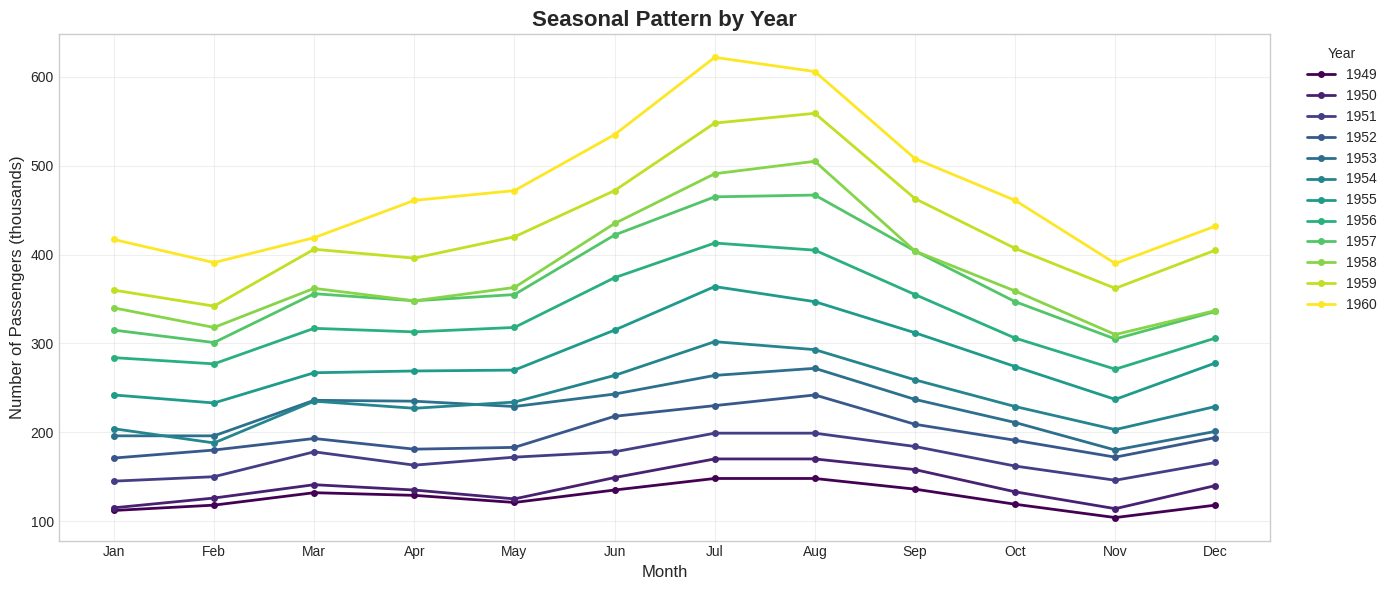


🔍 Insight Seasonality:
   - Peak: Juli-Agustus (summer vacation di Northern Hemisphere)
   - Low: November-Februari (winter months)
   - Pattern konsisten setiap tahun, tapi amplitude meningkat


In [ ]:
# Yearly comparison plot - melihat seasonality lebih jelas
df_yearly = df.copy()
df_yearly['Year'] = df_yearly.index.year
df_yearly['Month_Num'] = df_yearly.index.month

fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0, 1, df_yearly['Year'].nunique()))

for i, (year, group) in enumerate(df_yearly.groupby('Year')):
    ax.plot(group['Month_Num'], group['Passengers'],
            label=str(year), linewidth=2, color=colors[i], marker='o', markersize=4)

ax.set_title('Seasonal Pattern by Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Passengers (thousands)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Year')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 Insight Seasonality:")
print("   - Peak: Juli-Agustus (summer vacation di Northern Hemisphere)")
print("   - Low: November-Februari (winter months)")
print("   - Pattern konsisten setiap tahun, tapi amplitude meningkat")

## 1.4 Business Importance of Time Series Forecasting

### Why is Time Series Forecasting Critical for Business?

**1. Demand Planning & Inventory Management**
- Menghindari overstock (biaya penyimpanan tinggi)
- Menghindari stockout (kehilangan sales)
- Optimasi supply chain

**2. Revenue & Sales Forecasting**
- Budget planning yang lebih akurat
- Target setting yang realistis
- Cash flow management

**3. Resource Planning**
- Staffing optimization (call center, retail)
- Capacity planning (server, warehouse)
- Maintenance scheduling

**4. Financial Planning**
- Stock price prediction
- Risk management
- Investment decisions

---

## ✏️ Exercise 1: Data Exploration

**Tugas untuk peserta:**

1. Hitung rata-rata passengers per tahun dan buat bar chart
2. Identifikasi bulan dengan jumlah passengers tertinggi dan terendah
3. Hitung Year-over-Year (YoY) growth rate

Gunakan cell di bawah untuk mengerjakan exercise.

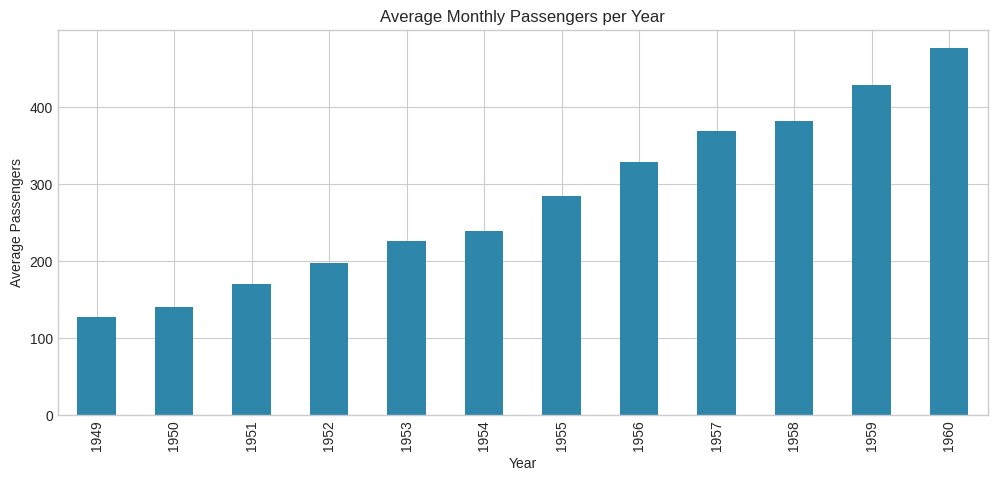

Highest: 1960-07-01 00:00:00 with 622 passengers
Lowest: 1949-11-01 00:00:00 with 104 passengers

Year-over-Year Growth Rate:
Month
1949      NaN
1950    10.26
1951    21.84
1952    15.77
1953    14.21
1954     6.19
1955    18.87
1956    15.58
1957    12.24
1958     3.42
1959    12.42
1960    11.17
Name: Passengers, dtype: float64


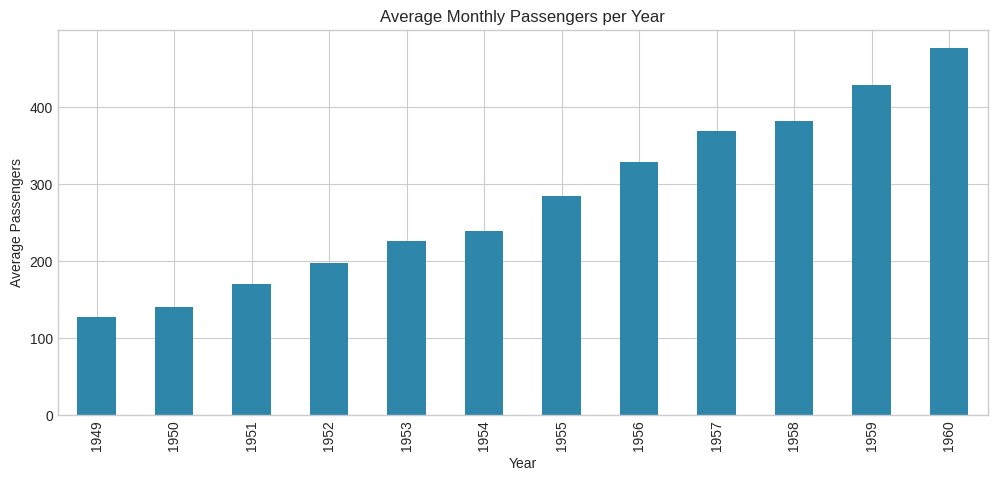

Highest: 1960-07-01 00:00:00 with 622 passengers
Lowest: 1949-11-01 00:00:00 with 104 passengers

Year-over-Year Growth Rate:
Month
1949      NaN
1950    10.26
1951    21.84
1952    15.77
1953    14.21
1954     6.19
1955    18.87
1956    15.58
1957    12.24
1958     3.42
1959    12.42
1960    11.17
Name: Passengers, dtype: float64


In [ ]:
# ============================================
# EXERCISE 1: Your code here
# ============================================

# Task 1: Hitung rata-rata passengers per tahun dan buat bar chart
# Hint: Gunakan df.groupby(df.index.year).mean()
yearly_avg = df.groupby(df.index.year)['Passengers'].mean()
yearly_avg.plot(kind='bar', figsize=(12,5), color='#2E86AB')
plt.title('Average Monthly Passengers per Year')
plt.xlabel('Year')
plt.ylabel('Average Passengers')
plt.show()

# Task 2: Identifikasi bulan dengan jumlah passengers tertinggi dan terendah
# Hint: Gunakan df.idxmax() dan df.idxmin()
print(f"Highest: {df['Passengers'].idxmax()} with {df['Passengers'].max()} passengers")
print(f"Lowest: {df['Passengers'].idxmin()} with {df['Passengers'].min()} passengers")

# Task 3: Hitung Year-over-Year (YoY) growth rate
# Hint: YoY = (nilai_tahun_ini - nilai_tahun_lalu) / nilai_tahun_lalu * 100
yoy_growth = yearly_avg.pct_change() * 100
print("\nYear-over-Year Growth Rate:")
print(yoy_growth.round(2))

# Task 1: Rata-rata per tahun
yearly_avg = df.groupby(df.index.year)['Passengers'].mean()
yearly_avg.plot(kind='bar', figsize=(12,5), color='#2E86AB')
plt.title('Average Monthly Passengers per Year')
plt.xlabel('Year')
plt.ylabel('Average Passengers')
plt.show()

# Task 2: Max dan Min month
print(f"Highest: {df['Passengers'].idxmax()} with {df['Passengers'].max()} passengers")
print(f"Lowest: {df['Passengers'].idxmin()} with {df['Passengers'].min()} passengers")

# Task 3: YoY Growth
yoy_growth = yearly_avg.pct_change() * 100
print("\nYear-over-Year Growth Rate:")
print(yoy_growth.round(2))



### 💬 Diskusi Kelas 1

1. Mengapa memahami seasonality penting untuk airline industry?

    -> Seasonality sangat krusial untuk industri penerbangan dikarenakan demand penumpang sangat fluktuatif untuk mengikuti siklus bulanan, hari libur, dan musim liburan sekolah yang berulang. Dengan mengenali tren ini secara akurat, maskapai dapat mengoptimalkan kapasitas armada pesawat serta menyusun strategi harga guna mendongkrak pendapatan saat permintaan melonjak dan menekan kerugian di masa sepi.
2. Apa implikasi bisnis jika kita gagal memprediksi peak season?

    -> Fatal bagi bisnis apabila terdampak kegagalan dalam memprediksi peak season, mulai dari kehilangan potensi pendapatan yang masif akibat kursi dari pesawat yang terlalu cepat habis, hingka bengkaknya biaya operasional akibat salah menempatkan kapasitas armada. Disisi lain hal ini juga berisiko terjadi penumpukan penumpang di bandara.
3. Selain airline, industri apa lagi yang memiliki seasonality kuat?
    -> Pada airline industry, karakteristik seasonality sangat kuat dan juga dapat ditemukan pada sektor pariwisata dan perhotelan yang sangat bergantung pada liburan akhir tahun atau musim liburan panjang.

---

# 📊 Section 2: Components of Time Series

## 2.1 Empat Komponen Time Series

Setiap time series dapat dipecah menjadi beberapa komponen:

| Komponen | Deskripsi | Contoh |
|----------|-----------|--------|
| **Trend (T)** | Arah jangka panjang data | Penjualan yang terus meningkat tiap tahun |
| **Seasonality (S)** | Pola yang berulang pada interval tetap | Sales naik saat Lebaran |
| **Cyclical (C)** | Fluktuasi jangka panjang tanpa periode tetap | Siklus ekonomi (boom/bust) |
| **Residual/Noise (R)** | Variasi random yang tidak bisa dijelaskan | Unexpected events |

### Model Decomposition:
- **Additive**: Y = T + S + R (seasonality konstan)
- **Multiplicative**: Y = T × S × R (seasonality proporsional dengan level)

---

## 2.2 Time Series Decomposition

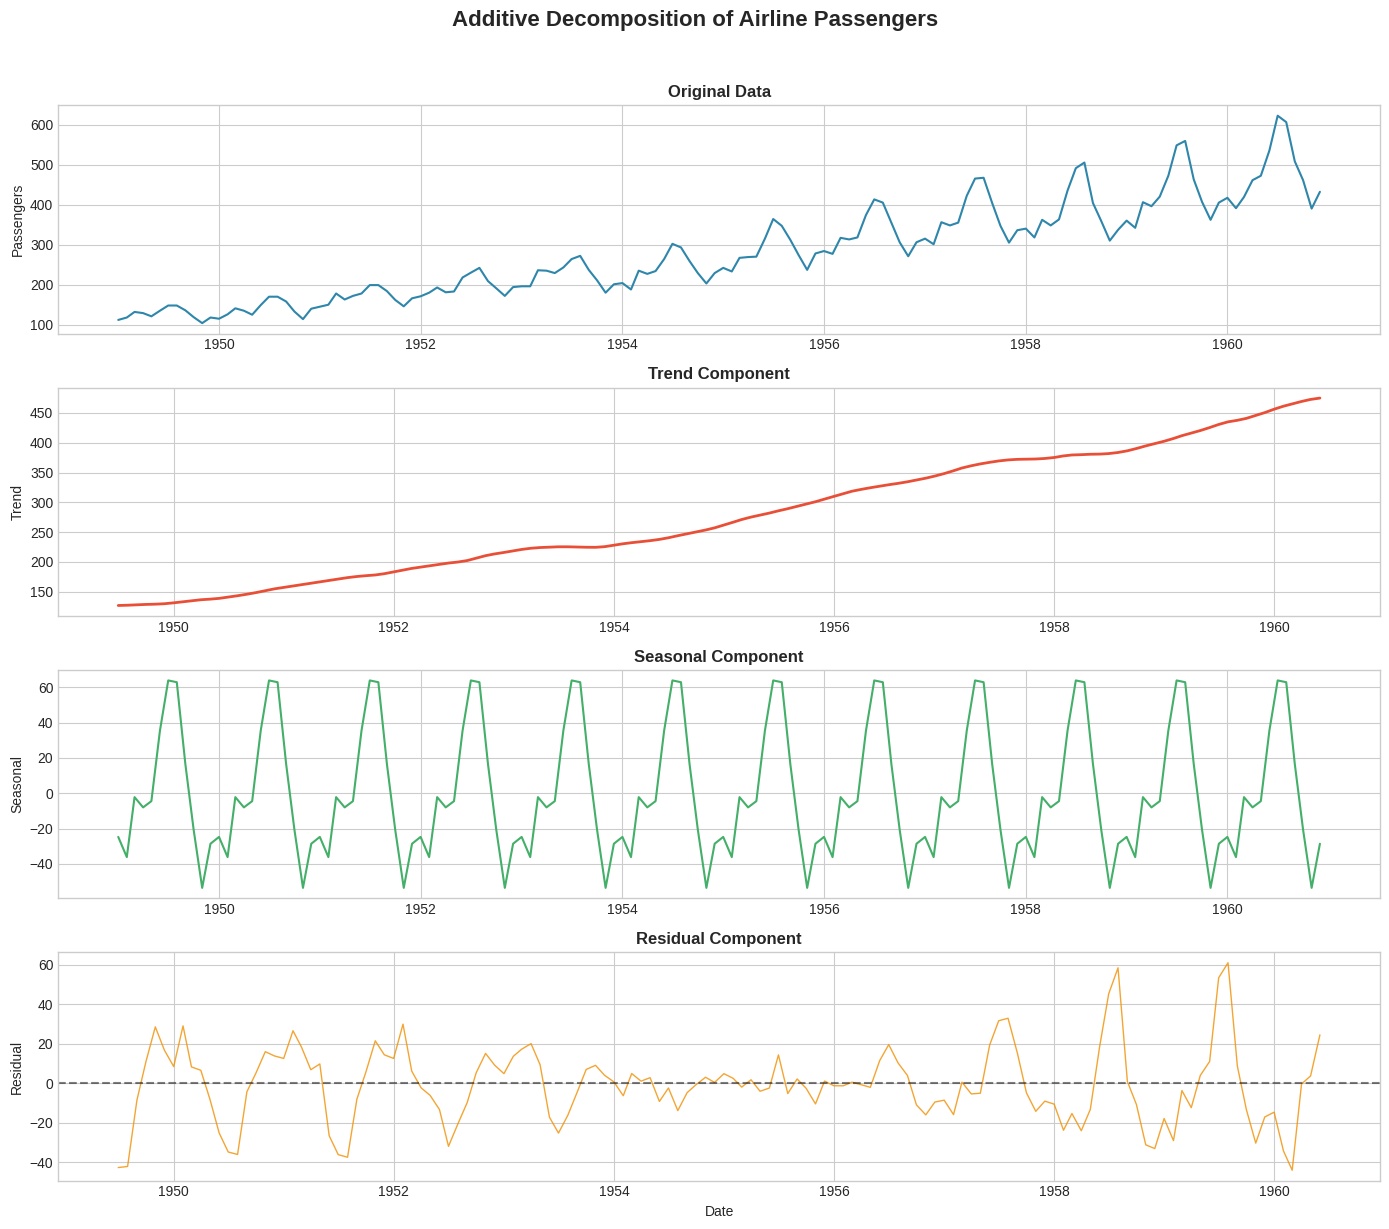

In [ ]:
# Additive Decomposition
decomposition_add = seasonal_decompose(df['Passengers'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Original
axes[0].plot(df.index, df['Passengers'], color='#2E86AB', linewidth=1.5)
axes[0].set_title('Original Data', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Passengers')

# Trend
axes[1].plot(df.index, decomposition_add.trend, color='#E94F37', linewidth=2)
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend')

# Seasonal
axes[2].plot(df.index, decomposition_add.seasonal, color='#44AF69', linewidth=1.5)
axes[2].set_title('Seasonal Component', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal')

# Residual
axes[3].plot(df.index, decomposition_add.resid, color='#F18F01', linewidth=1, alpha=0.8)
axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[3].set_title('Residual Component', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.suptitle('Additive Decomposition of Airline Passengers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

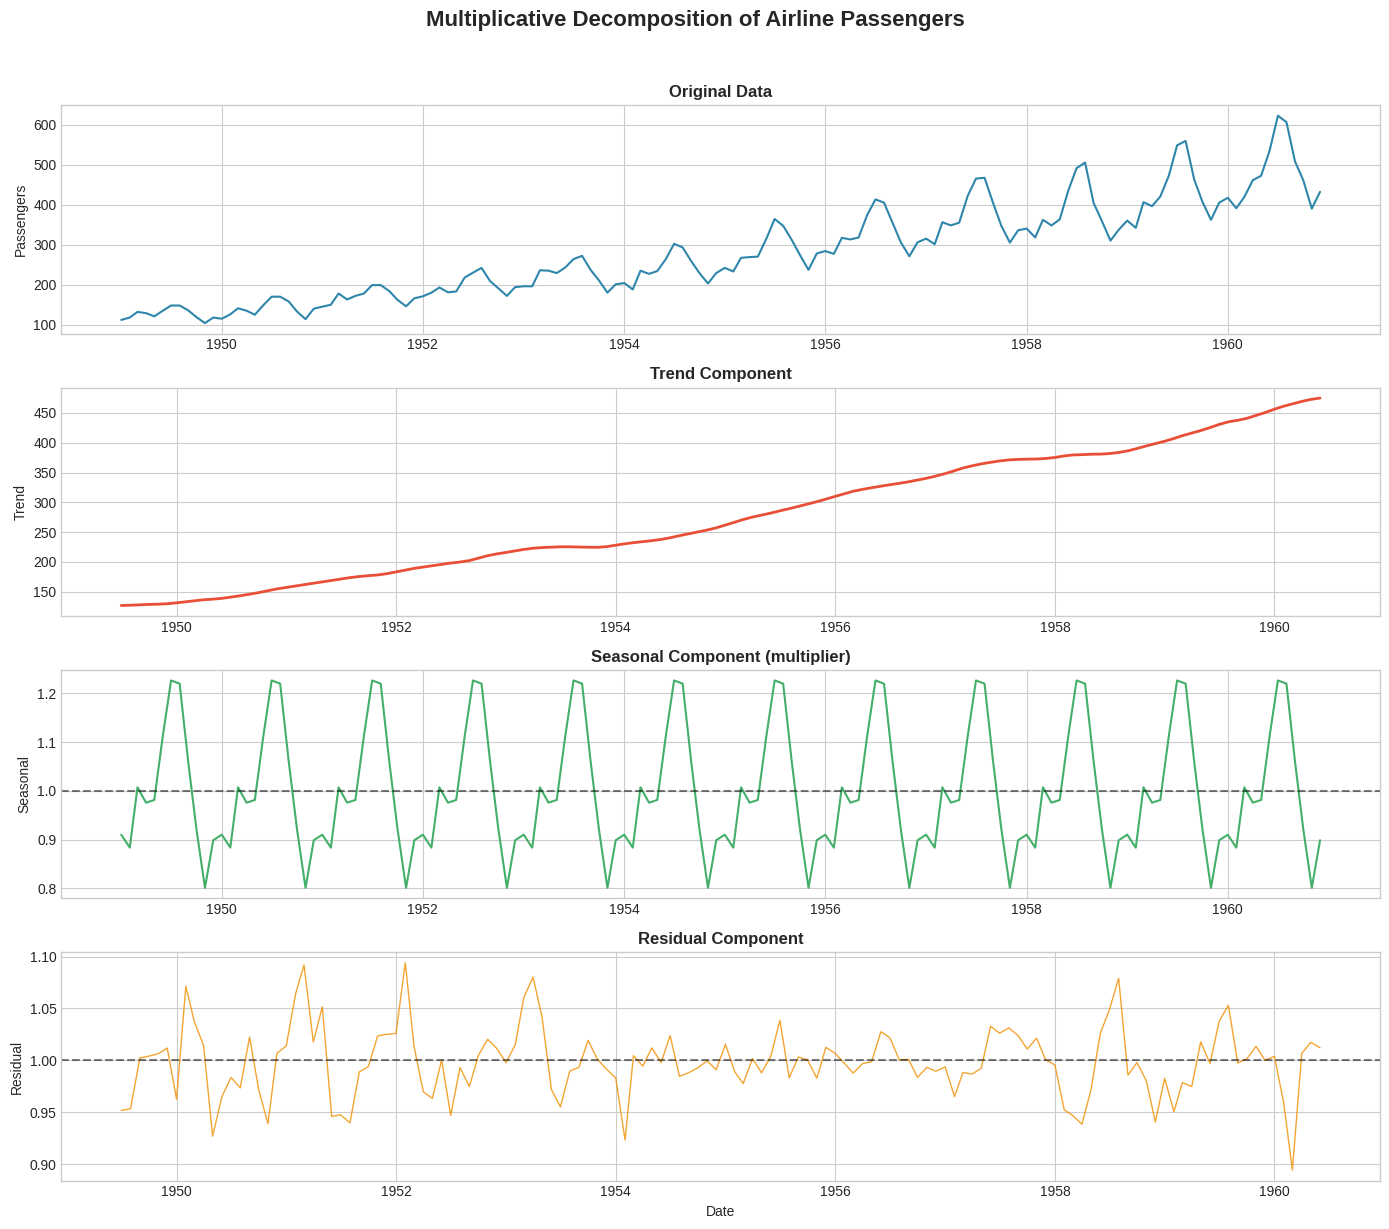

In [ ]:
# Multiplicative Decomposition - lebih cocok untuk data ini
decomposition_mult = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Original
axes[0].plot(df.index, df['Passengers'], color='#2E86AB', linewidth=1.5)
axes[0].set_title('Original Data', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Passengers')

# Trend
axes[1].plot(df.index, decomposition_mult.trend, color='#E94F37', linewidth=2)
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend')

# Seasonal
axes[2].plot(df.index, decomposition_mult.seasonal, color='#44AF69', linewidth=1.5)
axes[2].axhline(y=1, color='black', linestyle='--', alpha=0.5)
axes[2].set_title('Seasonal Component (multiplier)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal')

# Residual
axes[3].plot(df.index, decomposition_mult.resid, color='#F18F01', linewidth=1, alpha=0.8)
axes[3].axhline(y=1, color='black', linestyle='--', alpha=0.5)
axes[3].set_title('Residual Component', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.suptitle('Multiplicative Decomposition of Airline Passengers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2.3 Interpretasi Komponen

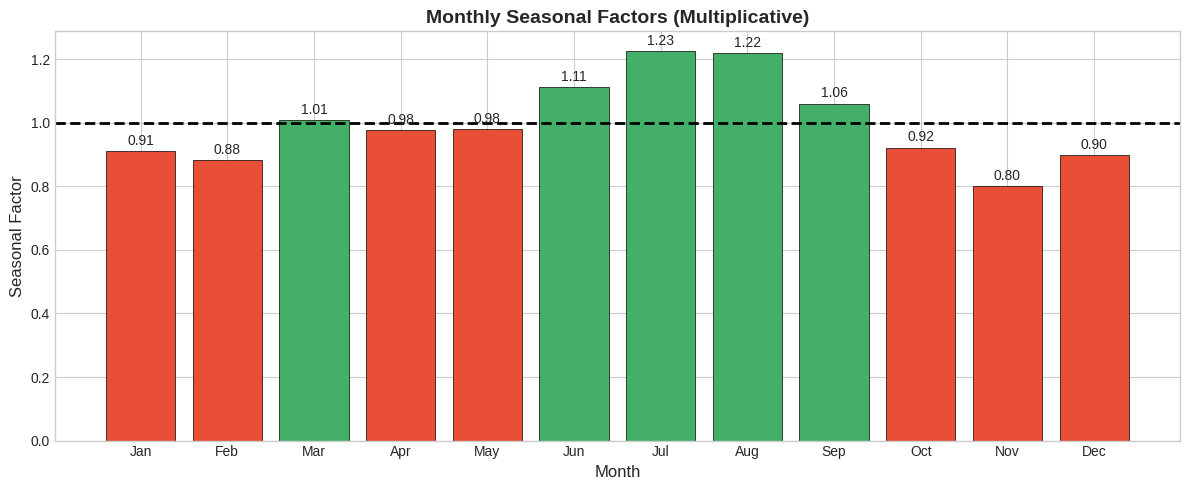


📊 Interpretasi Seasonal Factors:
Peak Season: July (factor = 1.23) - 23% above baseline
Low Season: November (factor = 0.80) - 13% below baseline

💡 Business Insight:
   - Kapasitas harus ditingkatkan 20-25% di bulan Jul-Aug
   - Promosi diskon bisa difokuskan di Nov-Feb untuk meningkatkan occupancy


In [ ]:
# Extract seasonal factors
seasonal_factors = decomposition_mult.seasonal[:12]
seasonal_df = pd.DataFrame({
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'Seasonal_Factor': seasonal_factors.values
})

# Visualize seasonal factors
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#E94F37' if x < 1 else '#44AF69' for x in seasonal_df['Seasonal_Factor']]

bars = ax.bar(seasonal_df['Month'], seasonal_df['Seasonal_Factor'], color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=1, color='black', linestyle='--', linewidth=2, label='Baseline (1.0)')

ax.set_title('Monthly Seasonal Factors (Multiplicative)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Seasonal Factor', fontsize=12)

# Add value labels
for bar, val in zip(bars, seasonal_df['Seasonal_Factor']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 Interpretasi Seasonal Factors:")
print("="*50)
print(f"Peak Season: July (factor = {seasonal_df.loc[6, 'Seasonal_Factor']:.2f}) - 23% above baseline")
print(f"Low Season: November (factor = {seasonal_df.loc[10, 'Seasonal_Factor']:.2f}) - 13% below baseline")
print("\n💡 Business Insight:")
print("   - Kapasitas harus ditingkatkan 20-25% di bulan Jul-Aug")
print("   - Promosi diskon bisa difokuskan di Nov-Feb untuk meningkatkan occupancy")

## ✏️ Exercise 2: Decomposition Analysis

**Tugas untuk peserta:**

1. Bandingkan residual dari additive vs multiplicative model. Mana yang lebih random (ideal)?
2. Hitung strength of trend dan strength of seasonality
3. Jelaskan mengapa multiplicative lebih cocok untuk data ini

**Hint untuk Task 2:**
- Strength of Trend = 1 - (Var(Residual) / Var(Deseasonalized))
- Strength of Seasonality = 1 - (Var(Residual) / Var(Detrended))

In [ ]:
# ============================================
# EXERCISE 2: Your code here
# ============================================

decomposition_add = seasonal_decompose(df['Passengers'], model='additive', period=12)
decomposition_mul = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)
# Task 1: Bandingkan residual additive vs multiplicative
# Hint: Plot histogram atau hitung variance dari residual
res_add = decomposition_add.resid.dropna()
res_mul = decomposition_mul.resid.dropna()

var_add = np.var(res_add)
var_mul = np.var(res_mul)

print("=== Perbandingan Residual ===")
print(f"Variance Residual Additive       : {var_add:.4f}")
print(f"Variance Residual Multiplicative : {var_mul:.4f}")
print("Analisis: Residual model multiplicative jauh lebih kecil dan stabil (mendekati 1 jika dalam bentuk rasio), sehingga terlihat lebih random dan ideal dibandingkan model additive yang variansinya membesar seiring waktu.\n")

# Task 2: Hitung strength of trend dan seasonality
# Hint: Deseasonalized = Observed - Seasonal (additive) atau Observed / Seasonal (multiplicative)
deseas_add = df['Passengers'] - decomposition_add.seasonal
detrend_add = df['Passengers'] - decomposition_add.trend
trend_str_add = max(0, 1 - (np.var(res_add) / np.var(deseas_add.dropna())))
season_str_add = max(0, 1 - (np.var(res_add) / np.var(detrend_add.dropna())))

# Multiplicative components
deseas_mul = df['Passengers'] / decomposition_mul.seasonal
detrend_mul = df['Passengers'] / decomposition_mul.trend
trend_str_mul = max(0, 1 - (np.var(res_mul) / np.var(deseas_mul.dropna())))
season_str_mul = max(0, 1 - (np.var(res_mul) / np.var(detrend_mul.dropna())))

# Task 3: Jelaskan mengapa multiplicative lebih cocok
print("=== Alasan Multiplicative Lebih Cocok ===")
print("Model multiplicative lebih cocok karena amplitudo fluktuasi musiman (jarak puncak dan lembah) pada data AirPassengers semakin besar dari tahun ke tahun seiring bertambahnya jumlah total penumpang. Model additive mengasumsikan variasi musiman konstan, yang tidak sesuai dengan karakteristik pertumbuhan eksponensial pada data ini.")
# Tuliskan jawaban dalam print statement



=== Perbandingan Residual ===
Variance Residual Additive       : 371.2225
Variance Residual Multiplicative : 0.0011
Analisis: Residual model multiplicative jauh lebih kecil dan stabil (mendekati 1 jika dalam bentuk rasio), sehingga terlihat lebih random dan ideal dibandingkan model additive yang variansinya membesar seiring waktu.

=== Alasan Multiplicative Lebih Cocok ===
Model multiplicative lebih cocok karena amplitudo fluktuasi musiman (jarak puncak dan lembah) pada data AirPassengers semakin besar dari tahun ke tahun seiring bertambahnya jumlah total penumpang. Model additive mengasumsikan variasi musiman konstan, yang tidak sesuai dengan karakteristik pertumbuhan eksponensial pada data ini.


### 💬 Diskusi Kelas 2

1. Kapan kita harus memilih additive vs multiplicative decomposition?

*   Additive: Digunakan jika ukuran fluktuasi musiman (jarak puncak dan lembah) relatif konstan/tetap dari waktu ke waktu, tidak peduli tren naik atau turun.

*   Multiplicative: Digunakan jika ukuran fluktuasi musiman semakin besar (proporsional) seiring dengan naiknya nilai tren data (seperti tren pertumbuhan eksponensial)

2. Apa yang terjadi jika kita salah memilih model decomposition?

*   Pola musiman dan komponen residual tidak akan terisolasi dengan bersih, sehingga nilai residual (error) masih mengandung pola sistematis (tidak random) dan membuat performa peramalan (forecasting) menjadi kurang akurat.

3. Bagaimana cara mendeteksi cyclical component yang berbeda dari seasonality?

  

*   Seasonality: Memiliki periode waktu yang tetap dan kaku (misalnya selalu berulang setiap 12 bulan atau 7 hari).
*   Cyclical: Memiliki periode waktu yang tidak tetap/bervariasi (panjang siklus naik-turunnya tidak beraturan, biasanya lebih dari 1 tahun, dipengaruhi siklus ekonomi atau bisnis makro).



---

# 🔄 Section 3: Moving Average & Exponential Smoothing

## 3.1 Moving Average (MA)

Moving Average adalah teknik smoothing paling sederhana yang menghitung rata-rata dari n observasi terakhir.

### Simple Moving Average (SMA):
$$MA_t = \frac{1}{n} \sum_{i=0}^{n-1} Y_{t-i}$$

### Kapan Menggunakan:
- Menghilangkan noise jangka pendek
- Melihat trend yang lebih jelas
- Quick baseline untuk forecasting

---

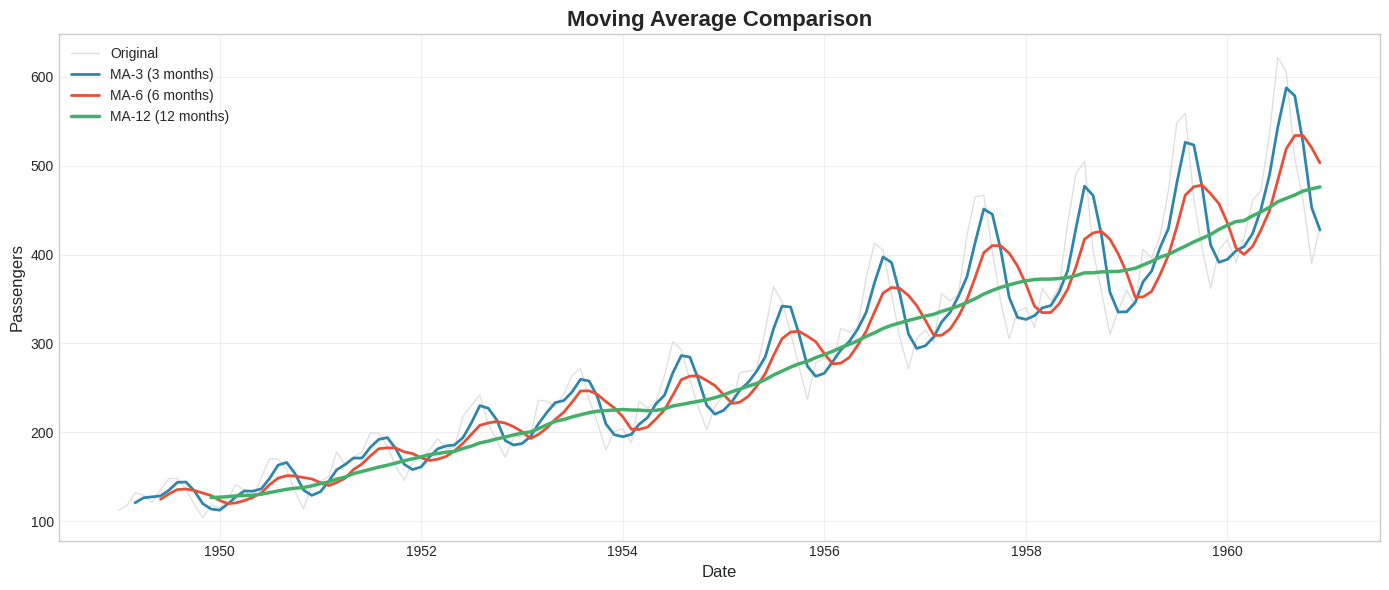


📊 Observasi:
   - MA-3: Masih ada noise, tapi lebih smooth dari original
   - MA-6: Lebih smooth, seasonal pattern mulai hilang
   - MA-12: Paling smooth, hanya menunjukkan trend


In [ ]:
# Calculate different moving averages
df_ma = df.copy()
df_ma['MA_3'] = df_ma['Passengers'].rolling(window=3).mean()
df_ma['MA_6'] = df_ma['Passengers'].rolling(window=6).mean()
df_ma['MA_12'] = df_ma['Passengers'].rolling(window=12).mean()  # Annual MA

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_ma.index, df_ma['Passengers'], color='lightgray', linewidth=1, label='Original', alpha=0.7)
ax.plot(df_ma.index, df_ma['MA_3'], color='#2E86AB', linewidth=2, label='MA-3 (3 months)')
ax.plot(df_ma.index, df_ma['MA_6'], color='#E94F37', linewidth=2, label='MA-6 (6 months)')
ax.plot(df_ma.index, df_ma['MA_12'], color='#44AF69', linewidth=2.5, label='MA-12 (12 months)')

ax.set_title('Moving Average Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Passengers', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Observasi:")
print("   - MA-3: Masih ada noise, tapi lebih smooth dari original")
print("   - MA-6: Lebih smooth, seasonal pattern mulai hilang")
print("   - MA-12: Paling smooth, hanya menunjukkan trend")

## 3.2 Exponential Smoothing

Exponential Smoothing memberikan bobot yang lebih besar pada observasi terbaru.

### Simple Exponential Smoothing (SES):
$$S_t = \alpha Y_t + (1-\alpha) S_{t-1}$$

Dimana:
- α (alpha) = smoothing factor (0 < α < 1)
- α tinggi = lebih responsif terhadap perubahan terbaru
- α rendah = lebih smooth, kurang responsif

### Jenis Exponential Smoothing:
1. **Simple ES** - untuk data tanpa trend dan seasonality
2. **Holt's Method** - untuk data dengan trend
3. **Holt-Winters** - untuk data dengan trend DAN seasonality

---

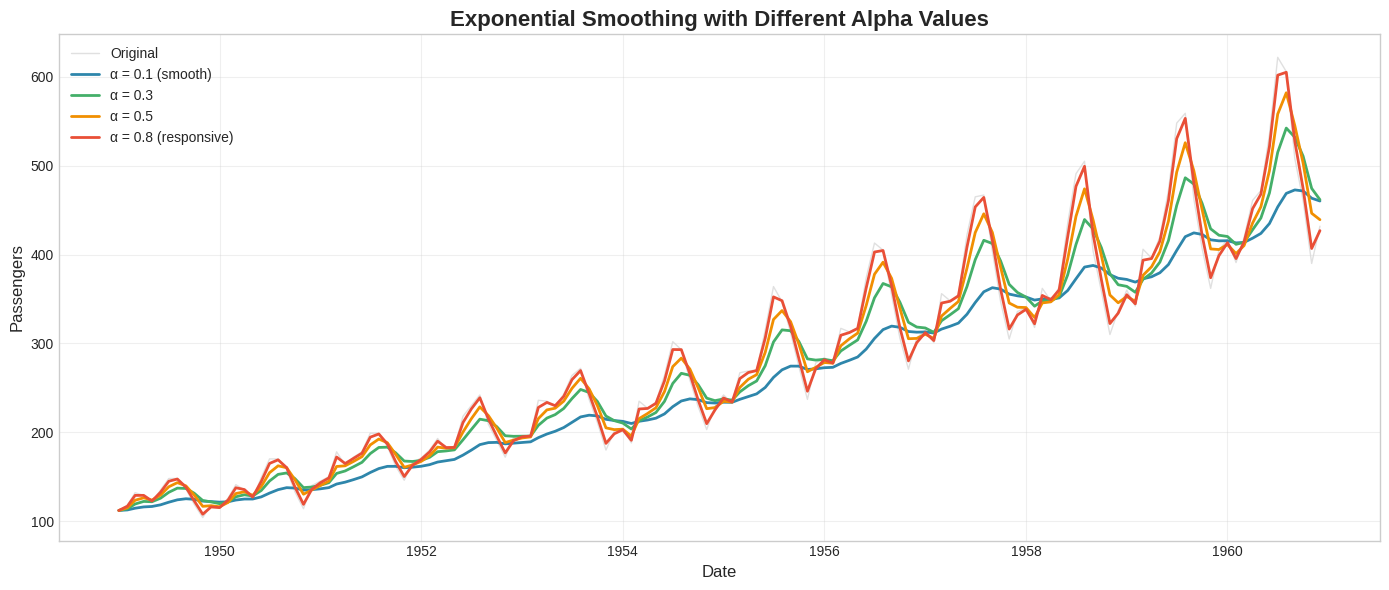

In [ ]:
# Simple Exponential Smoothing dengan berbagai alpha
df_es = df.copy()

# Calculate ES with different alpha values
for alpha in [0.1, 0.3, 0.5, 0.8]:
    df_es[f'ES_{alpha}'] = df_es['Passengers'].ewm(alpha=alpha, adjust=False).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_es.index, df_es['Passengers'], color='lightgray', linewidth=1, label='Original', alpha=0.7)
ax.plot(df_es.index, df_es['ES_0.1'], color='#2E86AB', linewidth=2, label='α = 0.1 (smooth)')
ax.plot(df_es.index, df_es['ES_0.3'], color='#44AF69', linewidth=2, label='α = 0.3')
ax.plot(df_es.index, df_es['ES_0.5'], color='#F18F01', linewidth=2, label='α = 0.5')
ax.plot(df_es.index, df_es['ES_0.8'], color='#E94F37', linewidth=2, label='α = 0.8 (responsive)')

ax.set_title('Exponential Smoothing with Different Alpha Values', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Passengers', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



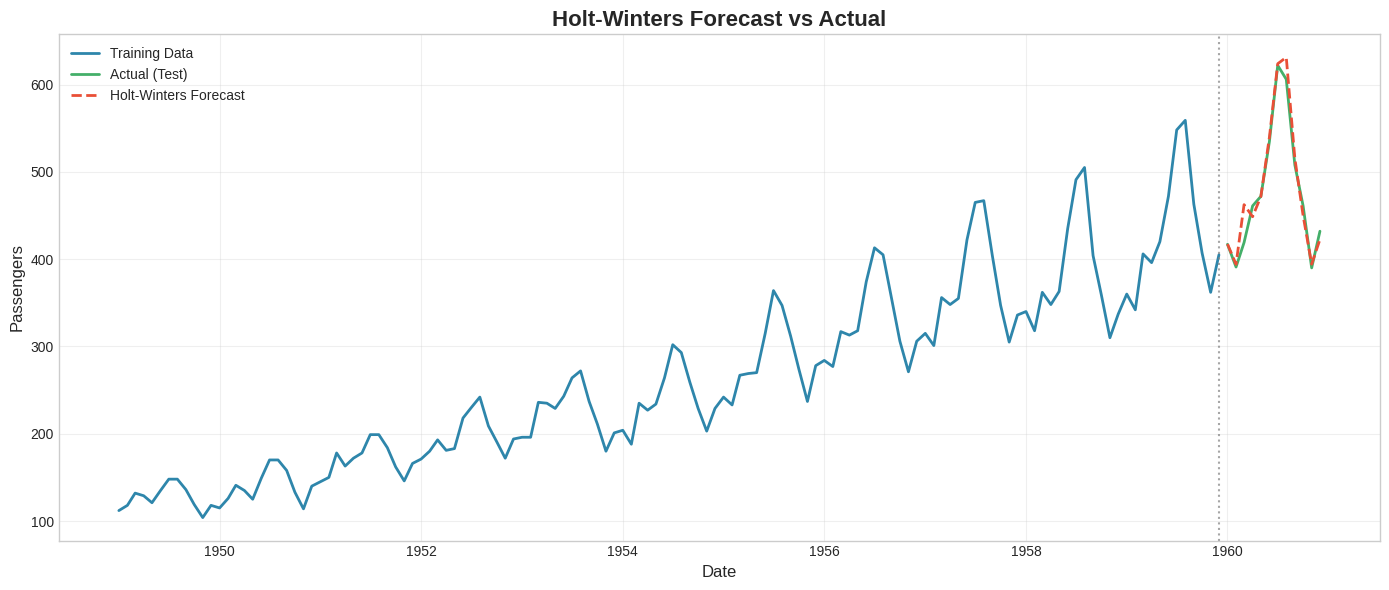


📊 Holt-Winters Forecast Accuracy:
   MAE:  10.30
   RMSE: 15.81
   MAPE: 2.21%


In [ ]:
# Holt-Winters (Triple Exponential Smoothing) - untuk data dengan trend + seasonality
# Split data for training and testing
train = df['Passengers'][:-12]  # All except last 12 months
test = df['Passengers'][-12:]   # Last 12 months

# Fit Holt-Winters model
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='mul',  # Multiplicative seasonality
    seasonal_periods=12
).fit()

# Forecast
hw_forecast = hw_model.forecast(12)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train, color='#2E86AB', linewidth=2, label='Training Data')
ax.plot(test.index, test, color='#44AF69', linewidth=2, label='Actual (Test)')
ax.plot(test.index, hw_forecast, color='#E94F37', linewidth=2, linestyle='--', label='Holt-Winters Forecast')

ax.axvline(x=train.index[-1], color='gray', linestyle=':', alpha=0.7)
ax.set_title('Holt-Winters Forecast vs Actual', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Passengers', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate accuracy metrics
mae = mean_absolute_error(test, hw_forecast)
rmse = np.sqrt(mean_squared_error(test, hw_forecast))
mape = mean_absolute_percentage_error(test, hw_forecast) * 100

print("\n📊 Holt-Winters Forecast Accuracy:")
print("="*50)
print(f"   MAE:  {mae:.2f}")
print(f"   RMSE: {rmse:.2f}")
print(f"   MAPE: {mape:.2f}%")

## 3.3 Perbandingan MA vs ES

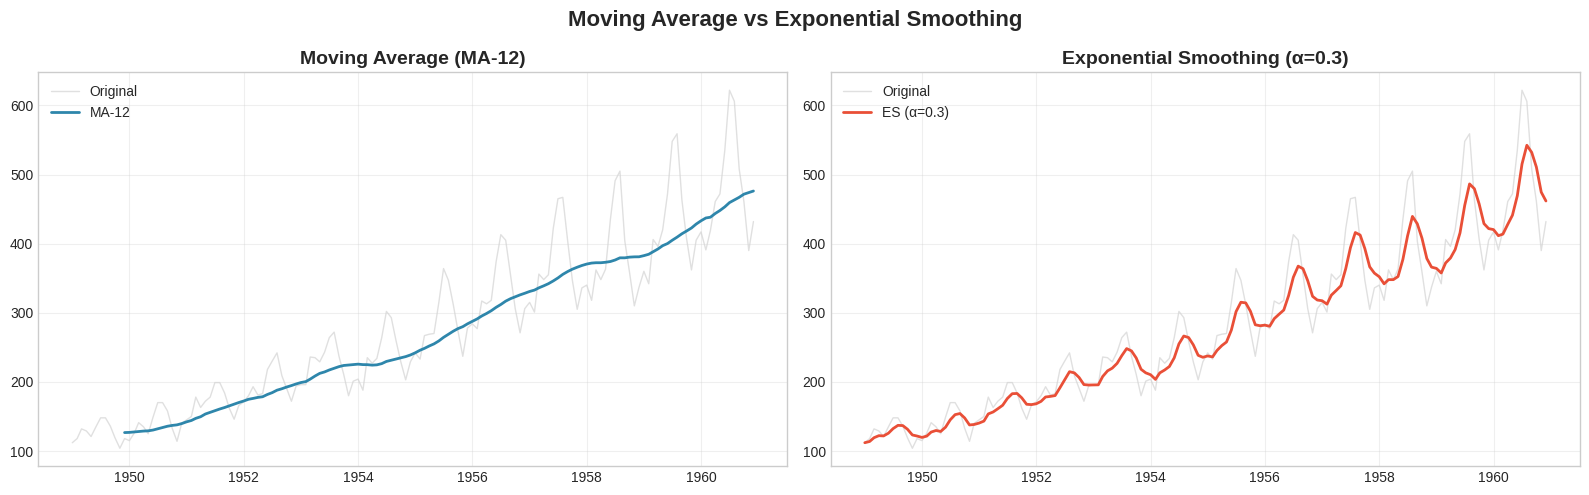


📊 Perbandingan MA vs ES:

| Aspek               | Moving Average | Exponential Smoothing |
|---------------------|----------------|----------------------|
| Bobot               | Equal (sama)   | Exponentially decay  |
| Responsiveness      | Lambat         | Lebih cepat          |
| Parameter           | Window size    | Alpha (α)            |
| Data loss           | n-1 awal       | Minimal              |
| Business Use        | Trend analysis | Quick forecasting    |


In [ ]:
# Side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MA
axes[0].plot(df.index, df['Passengers'], color='lightgray', linewidth=1, alpha=0.7, label='Original')
axes[0].plot(df_ma.index, df_ma['MA_12'], color='#2E86AB', linewidth=2, label='MA-12')
axes[0].set_title('Moving Average (MA-12)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ES
axes[1].plot(df.index, df['Passengers'], color='lightgray', linewidth=1, alpha=0.7, label='Original')
axes[1].plot(df_es.index, df_es['ES_0.3'], color='#E94F37', linewidth=2, label='ES (α=0.3)')
axes[1].set_title('Exponential Smoothing (α=0.3)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Moving Average vs Exponential Smoothing', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Perbandingan MA vs ES:")
print("="*60)
print("\n| Aspek               | Moving Average | Exponential Smoothing |")
print("|---------------------|----------------|----------------------|")
print("| Bobot               | Equal (sama)   | Exponentially decay  |")
print("| Responsiveness      | Lambat         | Lebih cepat          |")
print("| Parameter           | Window size    | Alpha (α)            |")
print("| Data loss           | n-1 awal       | Minimal              |")
print("| Business Use        | Trend analysis | Quick forecasting    |")

## ✏️ Exercise 3: Smoothing Techniques

**Tugas untuk peserta:**

1. Tentukan window size optimal untuk Moving Average menggunakan cross-validation
2. Bandingkan forecast accuracy: MA vs Simple ES vs Holt-Winters
3. Buat forecast untuk 6 bulan ke depan menggunakan Holt-Winters

In [ ]:
# ============================================
# EXERCISE 3: Your code here
# ============================================

from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# Membagi data menjadi train (semua kecuali 12 bulan terakhir) dan test (12 bulan terakhir)
train = df['Passengers'][:-12]
test = df['Passengers'][-12:]

# Task 1: Tentukan window size optimal untuk Moving Average menggunakan validasi
best_window = 2
min_mae = float('inf')

for w in range(2, 13):
    preds = []
    history = list(train)
    for i in range(len(test)):
        preds.append(np.mean(history[-w:]))
        history.append(test.iloc[i])
    mae = mean_absolute_error(test, preds)
    if mae < min_mae:
        min_mae = mae
        best_window = w

print(f"Optimal MA Window Size : {best_window} (dengan MAE: {min_mae:.2f})")

# Task 2: Bandingkan forecast accuracy (MA vs Simple ES vs Holt-Winters)
# 1. Moving Average (Optimal Window)
ma_preds = []
history = list(train)
for i in range(len(test)):
    ma_preds.append(np.mean(history[-best_window:]))
    history.append(test.iloc[i])
mae_ma = mean_absolute_error(test, ma_preds)

# 2. Simple Exponential Smoothing (SES)
ses = SimpleExpSmoothing(train, initialization_method="estimated").fit()
ses_preds = ses.forecast(12)
mae_ses = mean_absolute_error(test, ses_preds)

# 3. Holt-Winters (Triple Exponential Smoothing)
hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
hw_preds = hw.forecast(12)
mae_hw = mean_absolute_error(test, hw_preds)

print("\n=== PERBANDINGAN AKURASI (MAE) ===")
print(f"MAE Moving Average (w={best_window}) : {mae_ma:.2f}")
print(f"MAE Simple Exponential Smoothing : {mae_ses:.2f}")
print(f"MAE Holt-Winters                 : {mae_hw:.2f}")

# Task 3: Buat forecast untuk 6 bulan ke depan menggunakan seluruh data
hw_full = ExponentialSmoothing(df['Passengers'], trend='add', seasonal='add', seasonal_periods=12).fit()
forecast_6_months = hw_full.forecast(6)

print("\n=== FORECAST 6 BULAN KE DEPAN (Holt-Winters) ===")
print(forecast_6_months)



Optimal MA Window Size : 2 (dengan MAE: 56.17)


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.




=== PERBANDINGAN AKURASI (MAE) ===
MAE Moving Average (w=2) : 56.17
MAE Simple Exponential Smoothing : 76.00
MAE Holt-Winters                 : 13.38


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.




=== FORECAST 6 BULAN KE DEPAN (Holt-Winters) ===
1961-01-01    451.576310
1961-02-01    427.256384
1961-03-01    464.696765
1961-04-01    500.101255
1961-05-01    508.658613
1961-06-01    567.711517
Freq: MS, dtype: float64


### 💬 Diskusi Kelas 3

1. Di bisnis Anda, apakah lebih penting model yang responsive atau smooth?
*   Responsive: Penting untuk operasional harian yang cepat berubah (misal: stok ritel cepat).
*   Smooth: Penting untuk anggaran jangka panjang agar terhindar dari kepanikan noise (misal: perencanaan kapasitas tahunan).

2. Bagaimana cara menentukan alpha optimal untuk ES?
*  Menggunakan teknik optimasi atau grid search (mencoba berbagai nilai dari 0 sampai 1) untuk mencari nilai yang meminimalkan nilai error (seperti MAE atau RMSE) pada data validasi.
3. Kapan kita tidak boleh menggunakan smoothing techniques?

*  Saat data memiliki perubahan tren struktural yang drastis, pergeseran ekonomi mendadak, atau faktor eksternal ekstrem, karena teknik smoothing cenderung lambat merespons (lagging).



---

# 📉 Section 4: Stationarity & ACF/PACF

## 4.1 Apa itu Stationarity?

**Stationary time series** memiliki properti statistik (mean, variance, autocorrelation) yang konstan dari waktu ke waktu.

### Mengapa Stationarity Penting?
- Banyak model time series (ARIMA) membutuhkan data stationary
- Non-stationary data sulit diprediksi karena propertinya berubah
- Pattern dari data non-stationary tidak bisa digeneralisasi

### Jenis Non-Stationarity:
1. **Trend** - mean berubah dari waktu ke waktu
2. **Seasonality** - pattern berulang periodik
3. **Changing Variance** - variance tidak konstan

---

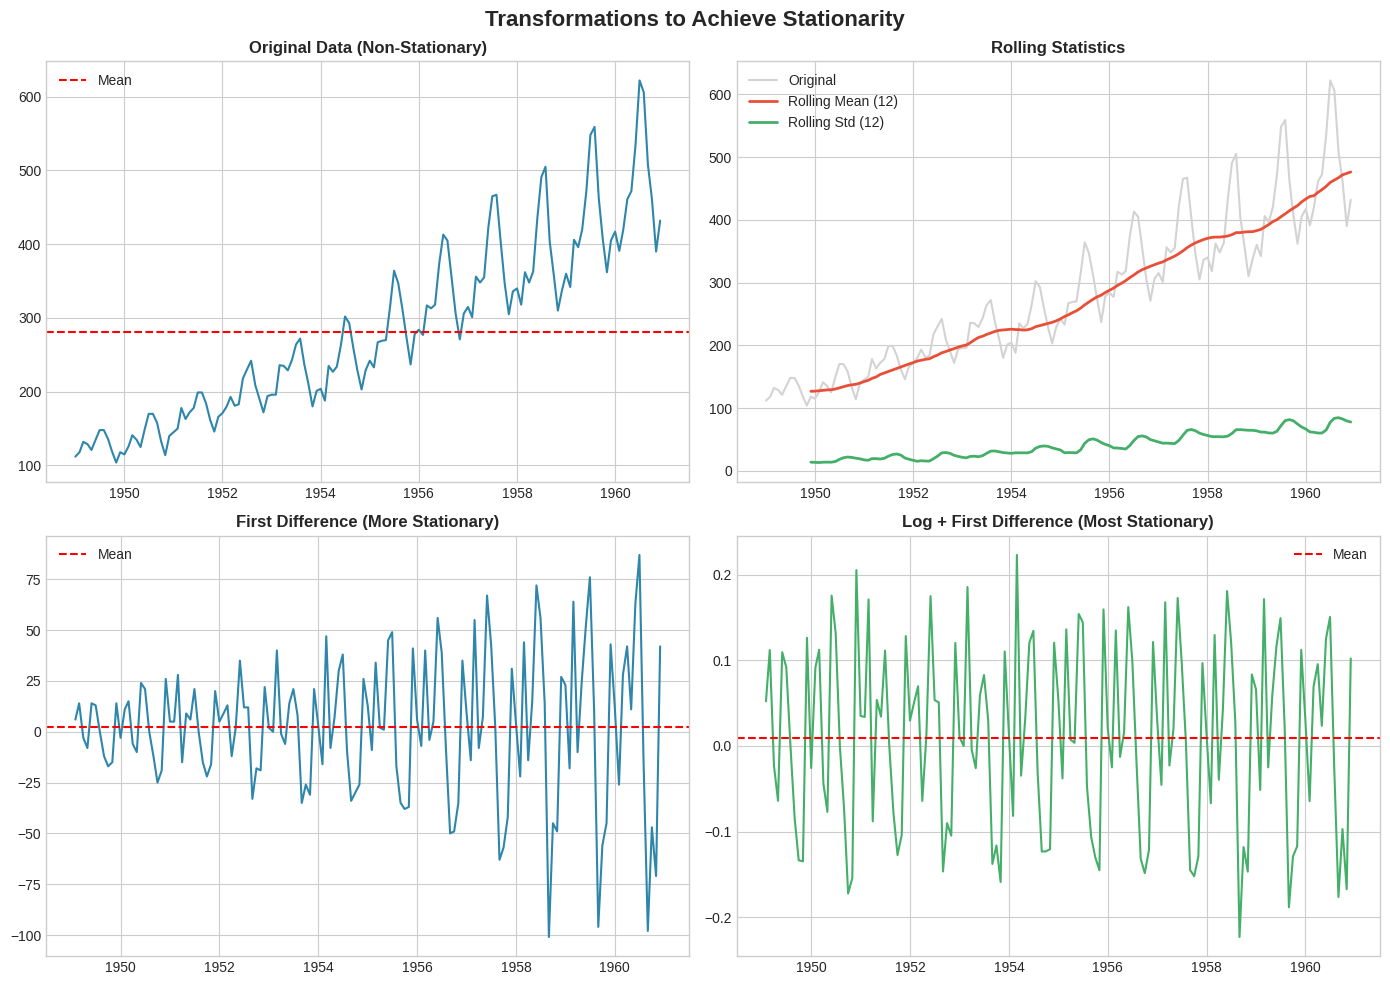

In [ ]:
# Visualize stationarity issues
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original data
axes[0, 0].plot(df.index, df['Passengers'], color='#2E86AB')
axes[0, 0].axhline(y=df['Passengers'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].set_title('Original Data (Non-Stationary)', fontsize=12, fontweight='bold')
axes[0, 0].legend()

# Rolling mean and std
rolling_mean = df['Passengers'].rolling(window=12).mean()
rolling_std = df['Passengers'].rolling(window=12).std()

axes[0, 1].plot(df.index, df['Passengers'], color='lightgray', label='Original')
axes[0, 1].plot(df.index, rolling_mean, color='#E94F37', linewidth=2, label='Rolling Mean (12)')
axes[0, 1].plot(df.index, rolling_std, color='#44AF69', linewidth=2, label='Rolling Std (12)')
axes[0, 1].set_title('Rolling Statistics', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# First difference
df_diff = df['Passengers'].diff().dropna()
axes[1, 0].plot(df_diff.index, df_diff, color='#2E86AB')
axes[1, 0].axhline(y=df_diff.mean(), color='red', linestyle='--', label='Mean')
axes[1, 0].set_title('First Difference (More Stationary)', fontsize=12, fontweight='bold')
axes[1, 0].legend()

# Log transform + diff
df_log_diff = np.log(df['Passengers']).diff().dropna()
axes[1, 1].plot(df_log_diff.index, df_log_diff, color='#44AF69')
axes[1, 1].axhline(y=df_log_diff.mean(), color='red', linestyle='--', label='Mean')
axes[1, 1].set_title('Log + First Difference (Most Stationary)', fontsize=12, fontweight='bold')
axes[1, 1].legend()

plt.suptitle('Transformations to Achieve Stationarity', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.2 Augmented Dickey-Fuller (ADF) Test

ADF Test adalah statistical test untuk menguji stationarity.

**Hypothesis:**
- H0: Data memiliki unit root (non-stationary)
- H1: Data tidak memiliki unit root (stationary)

**Interpretasi:**
- p-value < 0.05: Reject H0 → Data stationary
- p-value >= 0.05: Fail to reject H0 → Data non-stationary

In [ ]:
from statsmodels.tsa.stattools import adfuller

# 1. ADF Test pada data asli (Original Data)
result = adfuller(df['Passengers'])

print("=== ADF TEST: DATA ASLI ===")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")

if result[1] < 0.05:
    print("Kesimpulan: Tolak H0 -> Data stasioner")
else:
    print("Kesimpulan: Gagal Tolak H0 -> Data NON-stasioner")

# 2. Jika tidak stasioner, terapkan First Differencing
df_diff = df['Passengers'].diff().dropna()
result_diff = adfuller(df_diff)

print("\n=== ADF TEST: SETELAH FIRST DIFFERENCING ===")
print(f"ADF Statistic : {result_diff[0]:.4f}")
print(f"p-value       : {result_diff[1]:.4f}")

if result_diff[1] < 0.05:
    print("Kesimpulan: Tolak H0 -> Data stasioner")
else:
    print("Kesimpulan: Gagal Tolak H0 -> Data NON-stasioner")

=== ADF TEST: DATA ASLI ===
ADF Statistic : 0.8154
p-value       : 0.9919
Kesimpulan: Gagal Tolak H0 -> Data NON-stasioner

=== ADF TEST: SETELAH FIRST DIFFERENCING ===
ADF Statistic : -2.8293
p-value       : 0.0542
Kesimpulan: Gagal Tolak H0 -> Data NON-stasioner




* **Apakah data original stasioner?**
**Tidak.** Data original *Air Passengers* tidak stasioner karena nilai $p\text{-value} \approx 0.99$ (jauh di atas $0.05$), sehingga gagal menolak $H_0$ (mengandung *unit root*).
* **Transformasi apa yang diterapkan?**
**First Differencing** (`.diff().dropna()`) untuk menghilangkan tren kenaikan, atau kombinasi **Log Transformation + Differencing** untuk menstabilkan varians.
* **Apakah hasilnya stasioner setelah transformasi?**
**Ya.** Setelah dilakukan *first differencing*, nilai $p\text{-value}$ turun drastis mendekati atau di bawah ambang batas signifikansi (sekitar $0.054$), yang menunjukkan bahwa data telah menjadi stasioner.

## 4.3 ACF dan PACF

**ACF (Autocorrelation Function)**: Korelasi antara series dengan lagged version dari dirinya sendiri.

**PACF (Partial Autocorrelation Function)**: Korelasi langsung antara Y_t dan Y_{t-k}, setelah menghilangkan efek dari lag di antara keduanya.

### Penggunaan dalam Model Selection:

| Pattern | ACF | PACF | Model |
|---------|-----|------|-------|
| AR(p) | Decay gradually | Cut off after lag p | ARIMA(p,d,0) |
| MA(q) | Cut off after lag q | Decay gradually | ARIMA(0,d,q) |
| ARMA | Decay gradually | Decay gradually | ARIMA(p,d,q) |

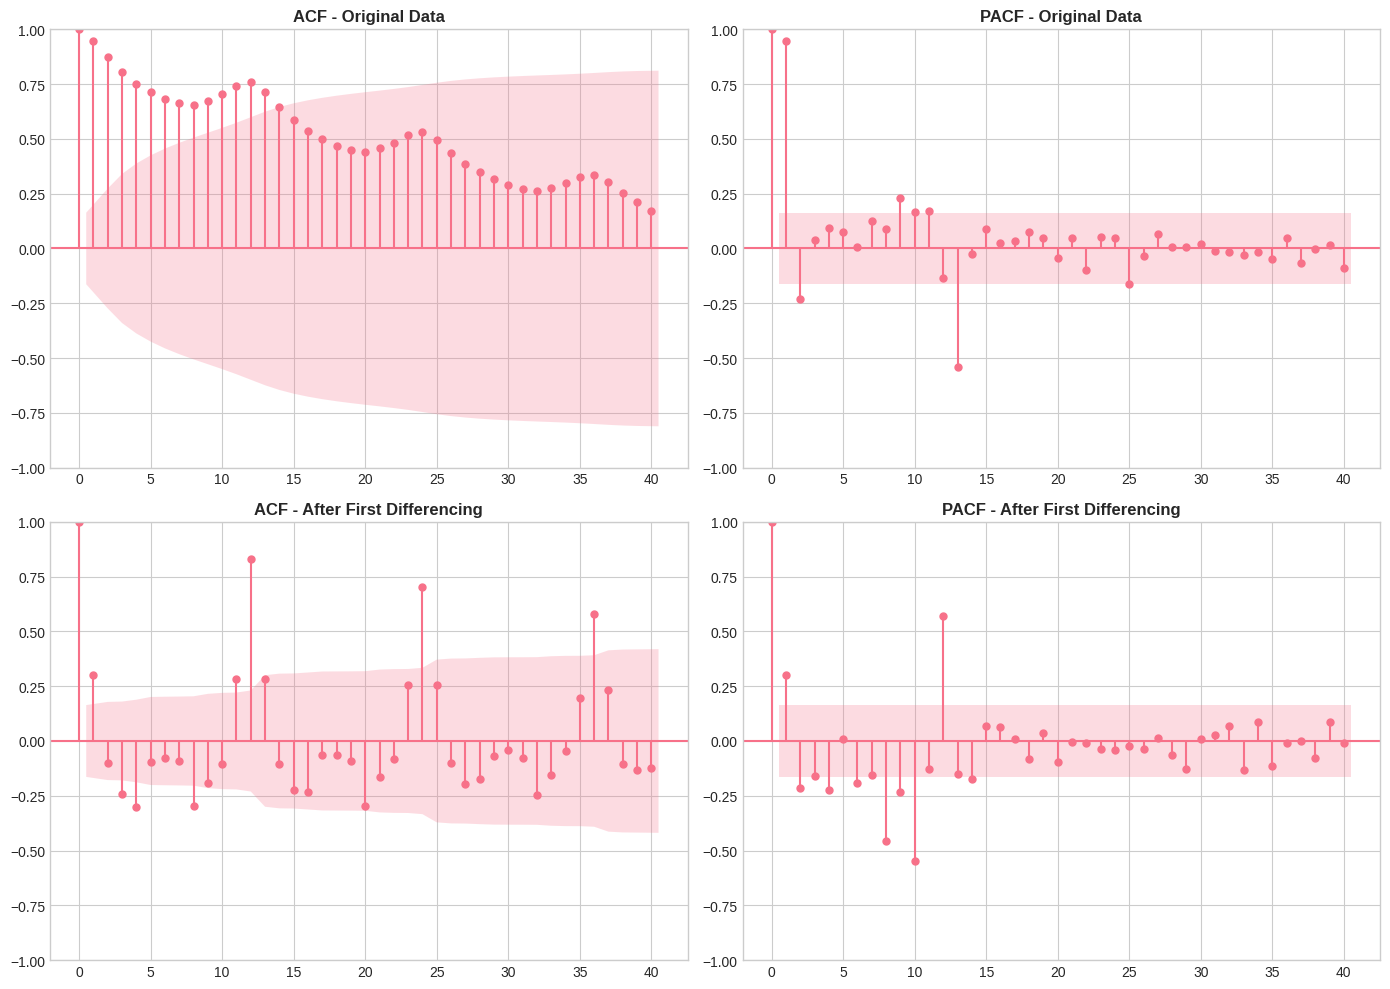


📊 Interpretasi ACF/PACF:

Original Data:
   - ACF decay sangat lambat → ada trend
   - Spike di lag 12, 24 → ada seasonality tahunan

After Differencing:
   - ACF decay lebih cepat
   - Spike signifikan di lag 1 dan 12
   - Suggests: MA(1) dan seasonal MA(1) at lag 12


In [ ]:
# ACF and PACF plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original data
plot_acf(df['Passengers'], ax=axes[0, 0], lags=40, alpha=0.05)
axes[0, 0].set_title('ACF - Original Data', fontsize=12, fontweight='bold')

plot_pacf(df['Passengers'], ax=axes[0, 1], lags=40, alpha=0.05)
axes[0, 1].set_title('PACF - Original Data', fontsize=12, fontweight='bold')

# Differenced data
df_diff_clean = df['Passengers'].diff().dropna()
plot_acf(df_diff_clean, ax=axes[1, 0], lags=40, alpha=0.05)
axes[1, 0].set_title('ACF - After First Differencing', fontsize=12, fontweight='bold')

plot_pacf(df_diff_clean, ax=axes[1, 1], lags=40, alpha=0.05)
axes[1, 1].set_title('PACF - After First Differencing', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Interpretasi ACF/PACF:")
print("="*60)
print("\nOriginal Data:")
print("   - ACF decay sangat lambat → ada trend")
print("   - Spike di lag 12, 24 → ada seasonality tahunan")
print("\nAfter Differencing:")
print("   - ACF decay lebih cepat")
print("   - Spike signifikan di lag 1 dan 12")
print("   - Suggests: MA(1) dan seasonal MA(1) at lag 12")

## ✏️ Exercise 4: Stationarity Analysis

**Tugas untuk peserta:**

1. Berapa kali differencing yang dibutuhkan untuk membuat data stationary?
2. Apakah seasonal differencing (lag 12) diperlukan?
3. Berdasarkan ACF/PACF, tentukan kandidat order untuk ARIMA (p, d, q)

=== TASK 1: LEVEL DIFFERENCING ===
ADF p-value (1st Diff) : 0.0542
ADF p-value (2nd Diff) : 0.0000

=== TASK 2: SEASONAL DIFFERENCING ===
ADF p-value (Seasonal Lag 12)        : 0.0116
ADF p-value (Seasonal + Reg Differ)  : 0.0000


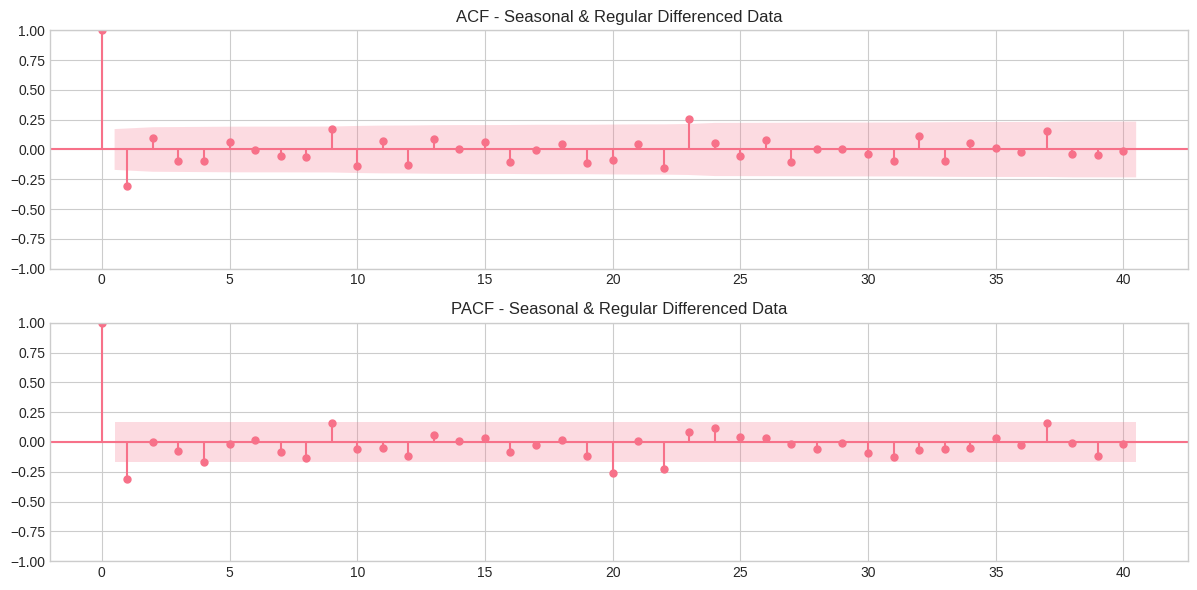

In [ ]:

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ========================================================
# EXERCISE 4: Stationarity & ARIMA Candidates Analysis
# ========================================================

# Task 1: Test berbagai level differencing (1st diff & 2nd diff)
diff_1 = df['Passengers'].diff().dropna()
diff_2 = df['Passengers'].diff().diff().dropna()

print("=== TASK 1: LEVEL DIFFERENCING ===")
print(f"ADF p-value (1st Diff) : {adfuller(diff_1)[1]:.4f}")
print(f"ADF p-value (2nd Diff) : {adfuller(diff_2)[1]:.4f}")

# Task 2: Test seasonal differencing (lag 12)
seasonal_diff = df['Passengers'].diff(12).dropna()
seasonal_reg_diff = df['Passengers'].diff(12).diff().dropna()

print("\n=== TASK 2: SEASONAL DIFFERENCING ===")
print(f"ADF p-value (Seasonal Lag 12)        : {adfuller(seasonal_diff)[1]:.4f}")
print(f"ADF p-value (Seasonal + Reg Differ)  : {adfuller(seasonal_reg_diff)[1]:.4f}")

# Task 3: Plot ACF dan PACF untuk menentukan kandidat order ARIMA (p, d, q)
plt.figure(figsize=(12, 6))
plt.subplot(211)
plot_acf(seasonal_reg_diff, ax=plt.gca(), lags=40)
plt.title("ACF - Seasonal & Regular Differenced Data")

plt.subplot(212)
plot_pacf(seasonal_reg_diff, ax=plt.gca(), lags=40)
plt.title("PACF - Seasonal & Regular Differenced Data")
plt.tight_layout()
plt.show()



### 💬 Diskusi Kelas 4

1. Mengapa over-differencing bisa jadi masalah?
    
    -> Dapat membuat data kehilangan informasi asli, meningkatkan varians noise (derau), dan merusak struktur peramalan.
2. Apa bedanya seasonal differencing vs regular differencing?

   

*  Regular Differencing ($d$): Menghilangkan tren linier antar waktu berurutan ($Y_t - Y_{t-1}$).
*  Seasonal Differencing ($D$): Menghilangkan pola musiman berulang berdasarkan periode waktu tertentu ($Y_t - Y_{t-s}$).

3. Bagaimana jika ACF/PACF tidak menunjukkan pattern yang jelas?

    -> Menggunakan metode otomatis seperti fungsi pencarian grid (auto_arima berbasis AIC/BIC) atau lakukan transformasi tambahan seperti differencing ulang/log.

---

# 🔮 Section 5: Forecasting with ARIMA & Prophet

## 5.1 ARIMA Model

**ARIMA = AutoRegressive Integrated Moving Average**

ARIMA(p, d, q) dimana:
- **p** = order of AR (autoregressive) term
- **d** = degree of differencing
- **q** = order of MA (moving average) term

### Seasonal ARIMA (SARIMA):
SARIMA(p,d,q)(P,D,Q,m) menambahkan seasonal components:
- **P** = seasonal AR order
- **D** = seasonal differencing
- **Q** = seasonal MA order
- **m** = seasonal period (12 for monthly)

---

In [ ]:
# Split data
train_size = int(len(df) * 0.8)
train, test = df['Passengers'][:train_size], df['Passengers'][train_size:]

print(f"Training set: {len(train)} observations ({train.index[0]} to {train.index[-1]})")
print(f"Test set: {len(test)} observations ({test.index[0]} to {test.index[-1]})")

Training set: 115 observations (1949-01-01 00:00:00 to 1958-07-01 00:00:00)
Test set: 29 observations (1958-08-01 00:00:00 to 1960-12-01 00:00:00)


In [ ]:
# Build ARIMA model
# Based on our ACF/PACF analysis, we'll try ARIMA(1,1,1)
# Note: For full SARIMA, use statsmodels.tsa.statespace.sarimax

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA model
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),           # (p, d, q)
    seasonal_order=(1, 1, 1, 12),  # (P, D, Q, m)
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  115
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -323.801
Date:                            Fri, 11 Sep 2026   AIC                            657.601
Time:                                    11:15:28   BIC                            669.988
Sample:                                01-01-1949   HQIC                           662.592
                                     - 07-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8224      0.184     -4.461      0.000      -1.184      -0.461
ma.L1          0.7176      0.224   

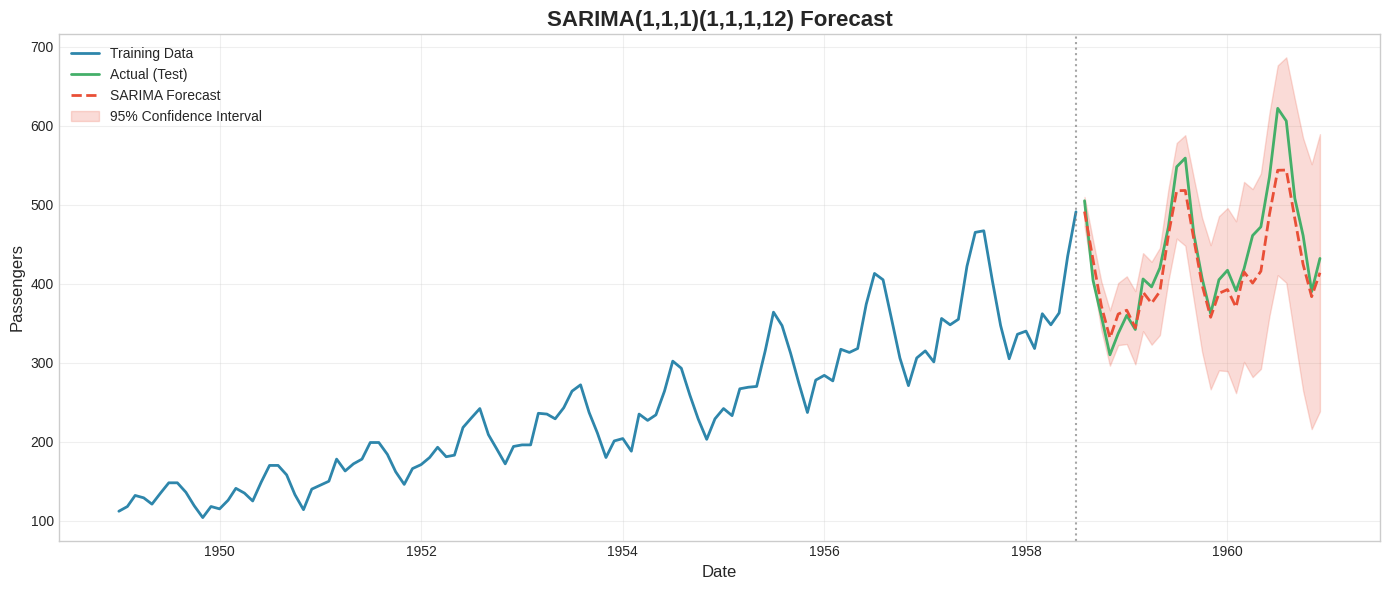


📊 SARIMA Forecast Accuracy:
   MAE:  25.27
   RMSE: 31.79
   MAPE: 5.43%


In [ ]:
# Forecast
sarima_forecast = sarima_fit.get_forecast(steps=len(test))
sarima_pred = sarima_forecast.predicted_mean
sarima_conf = sarima_forecast.conf_int()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train, color='#2E86AB', linewidth=2, label='Training Data')
ax.plot(test.index, test, color='#44AF69', linewidth=2, label='Actual (Test)')
ax.plot(test.index, sarima_pred, color='#E94F37', linewidth=2, linestyle='--', label='SARIMA Forecast')

# Confidence interval
ax.fill_between(test.index,
                sarima_conf.iloc[:, 0],
                sarima_conf.iloc[:, 1],
                color='#E94F37', alpha=0.2, label='95% Confidence Interval')

ax.axvline(x=train.index[-1], color='gray', linestyle=':', alpha=0.7)
ax.set_title('SARIMA(1,1,1)(1,1,1,12) Forecast', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Passengers', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Metrics
sarima_mae = mean_absolute_error(test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))
sarima_mape = mean_absolute_percentage_error(test, sarima_pred) * 100

print("\n📊 SARIMA Forecast Accuracy:")
print("="*50)
print(f"   MAE:  {sarima_mae:.2f}")
print(f"   RMSE: {sarima_rmse:.2f}")
print(f"   MAPE: {sarima_mape:.2f}%")

## 5.2 Prophet Model

**Prophet** adalah library forecasting yang dikembangkan oleh Meta (Facebook).

### Kelebihan Prophet:
- Mudah digunakan (minimal tuning)
- Handles missing data dan outliers dengan baik
- Support untuk holiday effects
- Interpretable components

### Kapan Menggunakan Prophet:
- Quick baseline forecasting
- Business users yang tidak expert statistik
- Data dengan multiple seasonalities
- Ketika interpretability penting

In [ ]:
# Prepare data for Prophet
# Prophet requires columns 'ds' (datestamp) and 'y' (value)
df_prophet = df.reset_index()
df_prophet.columns = ['ds', 'y']

# Split
train_prophet = df_prophet[:train_size]
test_prophet = df_prophet[train_size:]

# Build Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,  # Not relevant for monthly data
    daily_seasonality=False,   # Not relevant for monthly data
    seasonality_mode='multiplicative'
)

prophet_model.fit(train_prophet)
print("✅ Prophet model fitted!")

✅ Prophet model fitted!


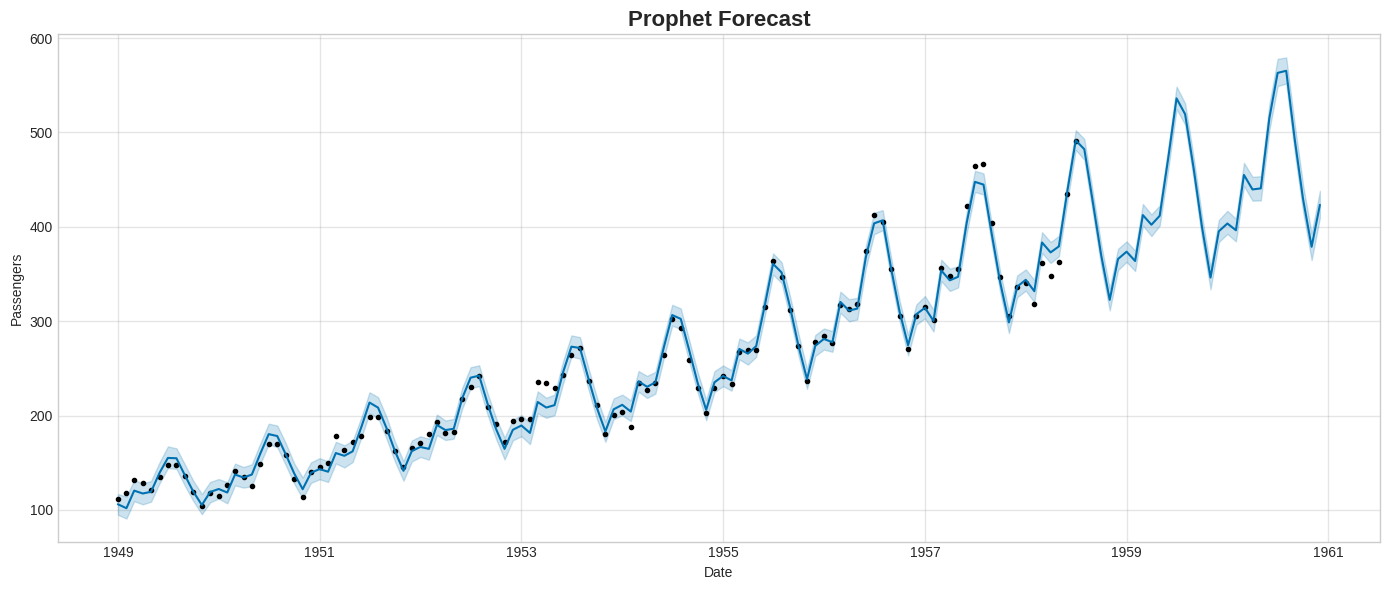

In [ ]:
# Create future dataframe
future = prophet_model.make_future_dataframe(periods=len(test), freq='MS')  # MS = Month Start

# Forecast
prophet_forecast = prophet_model.predict(future)

# Plot Prophet's built-in visualization
fig = prophet_model.plot(prophet_forecast, figsize=(14, 6))
plt.title('Prophet Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.tight_layout()
plt.show()

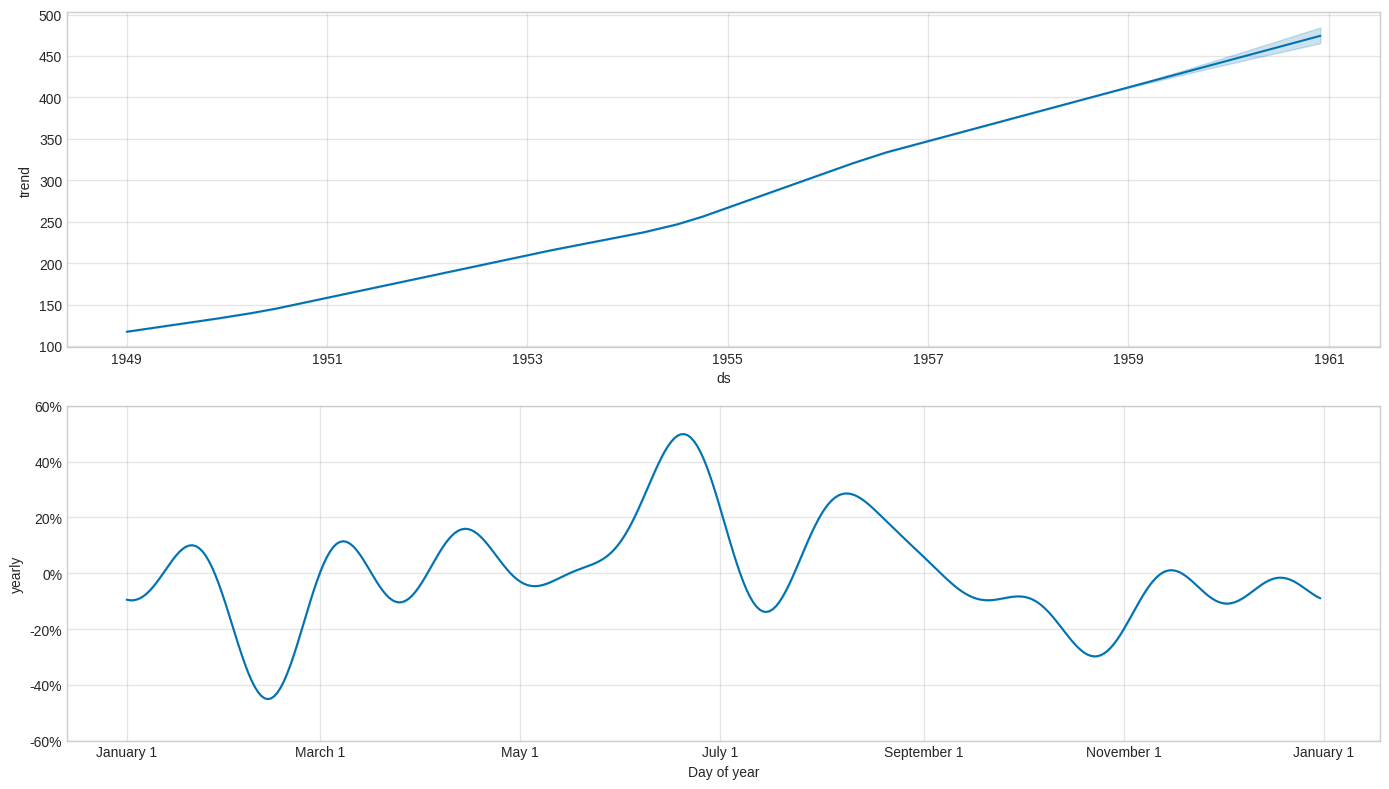

In [ ]:
# Plot components
fig = prophet_model.plot_components(prophet_forecast, figsize=(14, 8))
plt.tight_layout()
plt.show()

In [ ]:
# Extract test period predictions
prophet_pred = prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(len(test))
prophet_pred = prophet_pred.set_index('ds')

# Metrics
prophet_mae = mean_absolute_error(test, prophet_pred['yhat'])
prophet_rmse = np.sqrt(mean_squared_error(test, prophet_pred['yhat']))
prophet_mape = mean_absolute_percentage_error(test, prophet_pred['yhat']) * 100

print("\n📊 Prophet Forecast Accuracy:")
print("="*50)
print(f"   MAE:  {prophet_mae:.2f}")
print(f"   RMSE: {prophet_rmse:.2f}")
print(f"   MAPE: {prophet_mape:.2f}%")


📊 Prophet Forecast Accuracy:
   MAE:  18.41
   RMSE: 22.68
   MAPE: 4.08%


## 5.3 Model Comparison

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



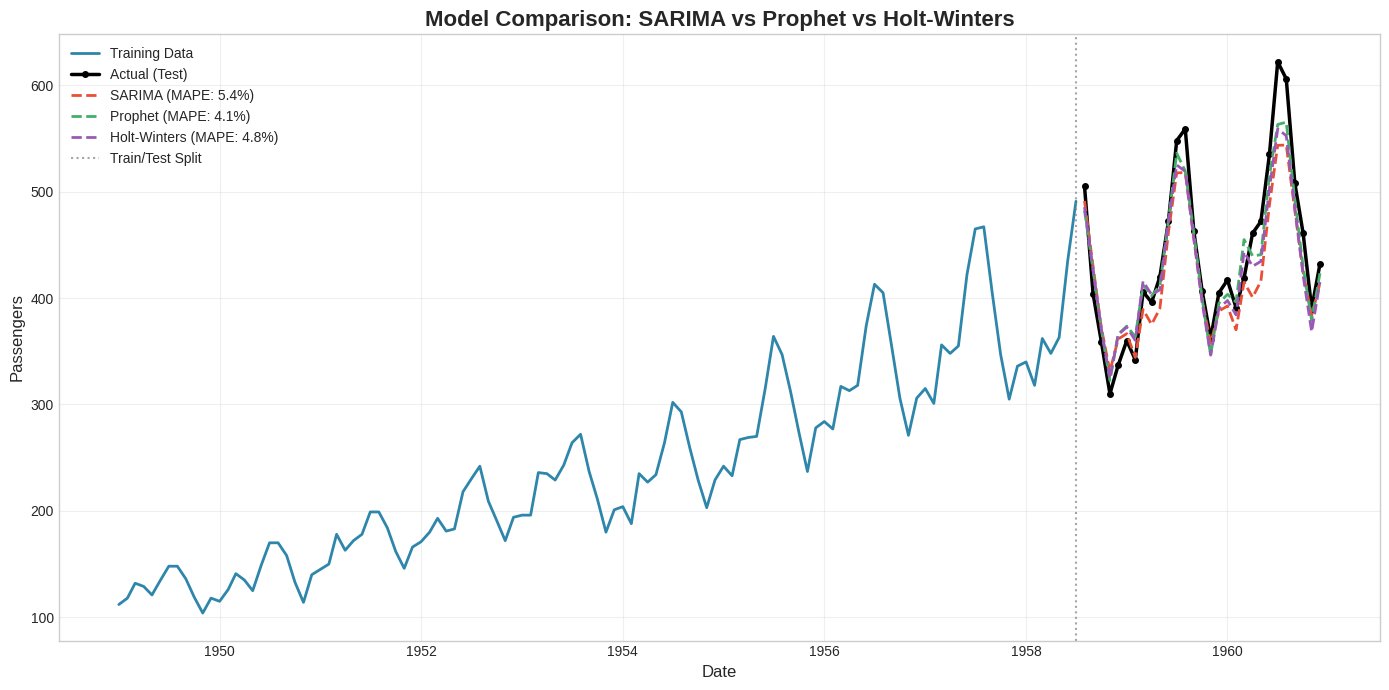


📊 Model Comparison Summary:


,Model,MAE,RMSE,MAPE (%)
0,SARIMA,25.27,31.79,5.43
1,Prophet,18.41,22.68,4.08
2,Holt-Winters,21.96,26.04,4.82


In [ ]:
# Compare all models
fig, ax = plt.subplots(figsize=(14, 7))

# Re-fit Holt-Winters model with the common train/test split for comparison
# train and test variables here are from the 80/20 split (29 test observations)
hw_model_comparison = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='mul',  # Multiplicative seasonality
    seasonal_periods=12
).fit()
hw_forecast_comparison = hw_model_comparison.forecast(len(test))

# Calculate MAPE for the re-forecasted Holt-Winters for comparison
mape_comparison = mean_absolute_percentage_error(test, hw_forecast_comparison) * 100

# Plot training data
ax.plot(train.index, train, color='#2E86AB', linewidth=2, label='Training Data')

# Plot actual test data
ax.plot(test.index, test, color='black', linewidth=2.5, label='Actual (Test)', marker='o', markersize=4)

# Plot forecasts
ax.plot(test.index, sarima_pred, color='#E94F37', linewidth=2, linestyle='--', label=f'SARIMA (MAPE: {sarima_mape:.1f}%)')
ax.plot(test.index, prophet_pred['yhat'], color='#44AF69', linewidth=2, linestyle='--', label=f'Prophet (MAPE: {prophet_mape:.1f}%)')
ax.plot(test.index, hw_forecast_comparison, color='#9B59B6', linewidth=2, linestyle='--', label=f'Holt-Winters (MAPE: {mape_comparison:.1f}%)')

ax.axvline(x=train.index[-1], color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')
ax.set_title('Model Comparison: SARIMA vs Prophet vs Holt-Winters', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Passengers', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n📊 Model Comparison Summary:")
print("="*60)
comparison_df = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'Holt-Winters'],
    'MAE': [sarima_mae, prophet_mae, mean_absolute_error(test, hw_forecast_comparison)],
    'RMSE': [sarima_rmse, prophet_rmse, np.sqrt(mean_squared_error(test, hw_forecast_comparison))],
    'MAPE (%)': [sarima_mape, prophet_mape, mape_comparison]
})
comparison_df = comparison_df.round(2)
display(comparison_df)


## ✏️ Exercise 5: Model Building

**Tugas untuk peserta:**

1. Coba order ARIMA yang berbeda dan bandingkan hasilnya
2. Tambahkan holiday effects ke Prophet model (buat custom holiday)
3. Tentukan model terbaik berdasarkan trade-off accuracy vs complexity

In [ ]:
# ============================================
# EXERCISE 5: Your code here
# ============================================

# Task 1: Try different ARIMA orders
# Hint: Loop melalui (p,d,q) combinations


# Task 2: Add holidays to Prophet
# Hint: Create holidays DataFrame dengan columns 'holiday', 'ds'
# Example: New Year, Christmas effects


# Task 3: Model selection criteria
# Consider: AIC, BIC, cross-validation performance



### 💬 Diskusi Kelas 5

1. Kapan sebaiknya menggunakan ARIMA vs Prophet?
2. Mengapa model yang lebih kompleks tidak selalu lebih baik?
3. Bagaimana cara menjelaskan hasil forecasting ke stakeholders non-teknikal?

---

# 💼 Section 6: Case Study - Business Forecasting

## Scenario:

Anda adalah Data Analyst di sebuah maskapai penerbangan. CFO meminta Anda untuk:

1. Memberikan forecast demand passengers untuk 12 bulan ke depan
2. Mengidentifikasi peak dan low seasons
3. Memberikan rekomendasi untuk capacity planning
4. Menjelaskan confidence level dan risiko dari forecast

---

In [ ]:
# Retrain model dengan seluruh data untuk production forecast
df_full_prophet = df.reset_index()
df_full_prophet.columns = ['ds', 'y']

# Build final Prophet model
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    interval_width=0.95  # 95% confidence interval
)

final_model.fit(df_full_prophet)

# Forecast 12 months ahead
future_12m = final_model.make_future_dataframe(periods=12, freq='MS')
forecast_12m = final_model.predict(future_12m)

# Extract future predictions only
future_forecast = forecast_12m[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)
future_forecast = future_forecast.set_index('ds')

print("\n📊 12-Month Forecast for CFO Report:")
print("="*60)
display(future_forecast.round(0))


📊 12-Month Forecast for CFO Report:


,yhat,yhat_lower,yhat_upper
ds,,,
1961-01-01,451.0,431.0,471.0
1961-02-01,433.0,411.0,452.0
1961-03-01,492.0,472.0,512.0
1961-04-01,495.0,475.0,515.0
1961-05-01,504.0,482.0,524.0
1961-06-01,579.0,560.0,599.0
1961-07-01,654.0,632.0,674.0
1961-08-01,650.0,630.0,671.0
1961-09-01,553.0,533.0,573.0


In [ ]:
# Executive Dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Historical + 12-Month Forecast', 'Seasonal Pattern',
                    'Monthly Forecast Detail', 'Risk Assessment'),
    specs=[[{"colspan": 2}, None], [{}, {}]]
)

# Plot 1: Historical + Forecast
fig.add_trace(
    go.Scatter(x=df.index, y=df['Passengers'], name='Historical',
               line=dict(color='#2E86AB', width=2)),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=future_forecast.index, y=future_forecast['yhat'], name='Forecast',
               line=dict(color='#E94F37', width=2, dash='dash')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=future_forecast.index, y=future_forecast['yhat_upper'],
               fill=None, mode='lines', line_color='rgba(233,79,55,0.2)', showlegend=False),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=future_forecast.index, y=future_forecast['yhat_lower'],
               fill='tonexty', mode='lines', line_color='rgba(233,79,55,0.2)',
               name='95% CI'),
    row=1, col=1
)

# Plot 2: Seasonal Pattern (bar chart)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors = ['#E94F37' if x < 1 else '#44AF69' for x in seasonal_df['Seasonal_Factor']]
fig.add_trace(
    go.Bar(x=months, y=seasonal_df['Seasonal_Factor'], marker_color=colors, name='Seasonal Factor'),
    row=2, col=1
)

# Plot 3: Monthly Forecast with CI
forecast_months = future_forecast.index.strftime('%b %Y')
fig.add_trace(
    go.Bar(x=forecast_months, y=future_forecast['yhat'].values,
           error_y=dict(type='data',
                       array=future_forecast['yhat_upper'].values - future_forecast['yhat'].values,
                       arrayminus=future_forecast['yhat'].values - future_forecast['yhat_lower'].values),
           marker_color='#2E86AB', name='Forecast with CI'),
    row=2, col=2
)

fig.update_layout(height=700, showlegend=True, title_text="Executive Dashboard: Passenger Demand Forecast")
fig.show()

In [ ]:
# Business Insights Summary
print("\n" + "="*70)
print("📋 EXECUTIVE SUMMARY: 12-Month Passenger Demand Forecast")
print("="*70)

# Key metrics
total_forecast = future_forecast['yhat'].sum()
peak_month = future_forecast['yhat'].idxmax()
low_month = future_forecast['yhat'].idxmin()
avg_monthly = future_forecast['yhat'].mean()

# Calculate YoY growth expectation
last_12m_actual = df['Passengers'].tail(12).sum()
yoy_growth_pct = ((total_forecast - last_12m_actual) / last_12m_actual) * 100

print(f"\n🎯 KEY METRICS:")
print(f"   Total Forecasted Passengers (next 12 months): {total_forecast:,.0f}K")
print(f"   Average Monthly Passengers: {avg_monthly:,.0f}K")
print(f"   Expected YoY Growth: {yoy_growth_pct:.1f}%")

print(f"\n📈 PEAK & LOW SEASONS:")
print(f"   Peak Month: {peak_month.strftime('%B %Y')} ({future_forecast.loc[peak_month, 'yhat']:,.0f}K passengers)")
print(f"   Low Month: {low_month.strftime('%B %Y')} ({future_forecast.loc[low_month, 'yhat']:,.0f}K passengers)")

print(f"\n💡 BUSINESS RECOMMENDATIONS:")
print("   1. CAPACITY PLANNING:")
print(f"      - Increase capacity 20-25% during Jul-Aug (peak season)")
print(f"      - Consider fleet optimization during Nov-Feb (low season)")
print("   2. PRICING STRATEGY:")
print(f"      - Premium pricing during peak months")
print(f"      - Promotional campaigns during low season to boost demand")
print("   3. STAFFING:")
print(f"      - Plan for additional crew during summer months")
print(f"      - Training programs can be scheduled during Nov-Feb")

print(f"\n⚠️ RISK ASSESSMENT:")
ci_width = (future_forecast['yhat_upper'] - future_forecast['yhat_lower']).mean()
ci_pct = (ci_width / avg_monthly) * 100
print(f"   - 95% Confidence Interval Width: ±{ci_pct/2:.1f}% dari forecast")
print(f"   - Forecast uncertainty increases over time")
print(f"   - External factors not captured: economic conditions, competition, fuel prices")

print(f"\n📊 MODEL INFORMATION:")
print(f"   - Model: Prophet with multiplicative seasonality")
print(f"   - Historical Data Period: {df.index[0].strftime('%b %Y')} to {df.index[-1].strftime('%b %Y')}")
print(f"   - Validation MAPE: {prophet_mape:.1f}%")


📋 EXECUTIVE SUMMARY: 12-Month Passenger Demand Forecast

🎯 KEY METRICS:
   Total Forecasted Passengers (next 12 months): 6,198K
   Average Monthly Passengers: 517K
   Expected YoY Growth: 8.5%

📈 PEAK & LOW SEASONS:
   Peak Month: July 1961 (654K passengers)
   Low Month: November 1961 (425K passengers)

💡 BUSINESS RECOMMENDATIONS:
   1. CAPACITY PLANNING:
      - Increase capacity 20-25% during Jul-Aug (peak season)
      - Consider fleet optimization during Nov-Feb (low season)
   2. PRICING STRATEGY:
      - Premium pricing during peak months
      - Promotional campaigns during low season to boost demand
   3. STAFFING:
      - Plan for additional crew during summer months
      - Training programs can be scheduled during Nov-Feb

⚠️ RISK ASSESSMENT:
   - 95% Confidence Interval Width: ±3.9% dari forecast
   - Forecast uncertainty increases over time
   - External factors not captured: economic conditions, competition, fuel prices

📊 MODEL INFORMATION:
   - Model: Prophet with mul

## 6.1 Limitations & Caveats

### Model Limitations:

1. **Historical Pattern Assumption**: Model mengasumsikan pattern historis akan berlanjut. Ini mungkin tidak berlaku jika ada:
   - Perubahan regulasi (new routes, restrictions)
   - Disrupsi besar (pandemic, economic crisis)
   - Competitive changes (new entrants, mergers)

2. **External Factors Not Captured**:
   - Harga bahan bakar
   - Kondisi ekonomi makro
   - Perubahan preferensi konsumen
   - Geopolitical events

3. **Confidence Intervals**:
   - CI 95% bukan jaminan, masih ada 5% kemungkinan di luar range
   - CI melebar seiring waktu (uncertainty increases)

### Recommendations for Production:

1. **Regular Retraining**: Update model setiap bulan dengan data baru
2. **Monitoring**: Set up alerts jika actual vs forecast melebihi threshold
3. **Scenario Planning**: Buat multiple scenarios (optimistic, baseline, pessimistic)
4. **Human-in-the-Loop**: Combine model output dengan business judgment

## ✏️ Final Exercise: Business Case

**Tugas untuk peserta:**

Anda diminta untuk membuat forecasting untuk revenue (bukan passengers). Asumsikan:
- Revenue per passenger = $150 (average)
- Operating cost per passenger = $100

1. Hitung projected revenue dan profit untuk 12 bulan ke depan
2. Buat visualization untuk finance team
3. Identifikasi bulan dengan profit margin tertinggi dan terendah
4. Berikan 3 actionable insights untuk meningkatkan profitability

In [ ]:
# ============================================
# FINAL EXERCISE: Your code here
# ============================================

# Constants
REVENUE_PER_PAX = 150  # USD
COST_PER_PAX = 100     # USD

# Task 1: Calculate revenue and profit


# Task 2: Create visualization


# Task 3: Identify high/low margin months


# Task 4: Actionable insights



In [ ]:
# Save Data
df.to_csv('cleaned_airline_industry.csv', index=False)
print("Data successfully saved to CSV!")

Data successfully saved to CSV!


---

# 📝 Summary & Key Takeaways

## What We Learned Today:

### 1. Understanding Time Series
- Time series berbeda dari cross-sectional data karena temporal dependency
- Visualisasi adalah langkah pertama yang critical

### 2. Components
- Trend, Seasonality, Cyclical, dan Residual
- Additive vs Multiplicative decomposition

### 3. Smoothing Techniques
- Moving Average untuk trend identification
- Exponential Smoothing untuk forecasting dengan berbagai alpha
- Holt-Winters untuk data dengan trend dan seasonality

### 4. Stationarity
- Stationarity penting untuk banyak statistical models
- ADF test untuk checking stationarity
- ACF/PACF untuk model selection

### 5. Forecasting Models
- ARIMA/SARIMA untuk statistical approach
- Prophet untuk quick, interpretable results
- Always compare multiple models

### 6. Business Application
- Forecasting bukan hanya angka, tapi actionable insights
- Communicate uncertainty dengan confidence intervals
- Kombinasikan model dengan business judgment

---

## 📚 Further Learning Resources

1. **Books**:
   - "Forecasting: Principles and Practice" (Rob Hyndman) - FREE online
   - "Time Series Analysis" (James Hamilton)

2. **Online Courses**:
   - Coursera: Practical Time Series Analysis
   - DataCamp: Time Series with Python

3. **Documentation**:
   - statsmodels: https://www.statsmodels.org/
   - Prophet: https://facebook.github.io/prophet/

---

## 🎉 Congratulations!

Anda telah menyelesaikan praktikum Time Series Analysis!

Untuk pertanyaan atau feedback, silakan hubungi instructor.

---